# Datathon 2026 — Comprehensive EDA

**Targets:** Revenue + COGS (both required in submission)  
**Train:** 2012-07-04 → 2022-12-31 (3,833 daily rows)  
**Test:** 2023-01-01 → 2024-07-01 (548 days)  
**Evaluation:** MAE, RMSE, R²  
**Domain:** Vietnamese fashion e-commerce

In [1]:
# Cell 1: Imports & Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.feature_selection import mutual_info_regression
import holidays as hol
import json
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

DATA_DIR = '../dataset/'
PROC_DIR = '../eda_results/processed/'
OUT_DIR  = '../eda_results/'
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print("Setup complete. Data dir:", DATA_DIR)


Setup complete. Data dir: ../dataset/


## Cell 2: Initialize Findings JSON Schema

In [2]:
# Cell 2: Initialize findings dict (schema-first)
findings = {
    "problem": {
        "target": ["Revenue", "COGS"],
        "train_span": {"start": "2012-07-04", "end": "2022-12-31"},
        "test_span":  {"start": "2023-01-01", "end": "2024-07-01"},
        "horizon_days": 548,
        "evaluation_metrics": ["MAE", "RMSE", "R2"]
    },
    "external_availability": {},
    "data_quality": {},
    "target_stats": {},
    "stationarity": {},
    "seasonality": {},
    "autocorrelation": {},
    "temporal_patterns": {},
    "transaction_features": {},
    "correlation_with_revenue": {},
    "outliers": {},
    "lag_analysis": {},
    "recommended_models": []
}
print("Findings schema initialized. Keys:", list(findings.keys()))


Findings schema initialized. Keys: ['problem', 'external_availability', 'data_quality', 'target_stats', 'stationarity', 'seasonality', 'autocorrelation', 'temporal_patterns', 'transaction_features', 'correlation_with_revenue', 'outliers', 'lag_analysis', 'recommended_models']


## Section 1: Data Overview & Quality

In [3]:
# Cell 3: Load all datasets
print("Loading datasets...")
sales       = pd.read_csv(DATA_DIR + 'sales.csv',       parse_dates=['Date'])
web         = pd.read_csv(DATA_DIR + 'web_traffic.csv', parse_dates=['date'])
customers   = pd.read_csv(DATA_DIR + 'customers.csv',   parse_dates=['signup_date'])
products    = pd.read_csv(DATA_DIR + 'products.csv')
promotions  = pd.read_csv(DATA_DIR + 'promotions.csv',  parse_dates=['start_date','end_date'])
geography   = pd.read_csv(DATA_DIR + 'geography.csv')
inventory   = pd.read_csv(DATA_DIR + 'inventory.csv',   parse_dates=['snapshot_date'])
orders      = pd.read_csv(DATA_DIR + 'orders.csv',      parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR + 'order_items.csv')
payments    = pd.read_csv(DATA_DIR + 'payments.csv')
shipments   = pd.read_csv(DATA_DIR + 'shipments.csv',   parse_dates=['ship_date','delivery_date'])
returns     = pd.read_csv(DATA_DIR + 'returns.csv',     parse_dates=['return_date'])
reviews     = pd.read_csv(DATA_DIR + 'reviews.csv',     parse_dates=['review_date'])
sample_sub  = pd.read_csv(DATA_DIR + 'sample_submission.csv', parse_dates=['Date'])

datasets = {
    'sales': sales, 'web_traffic': web, 'customers': customers,
    'products': products, 'promotions': promotions, 'geography': geography,
    'inventory': inventory, 'orders': orders, 'order_items': order_items,
    'payments': payments, 'shipments': shipments, 'returns': returns,
    'reviews': reviews
}
print("All datasets loaded.")
print(f"Sample submission columns: {list(sample_sub.columns)}")
print(f"Sample submission shape: {sample_sub.shape}")


Loading datasets...


All datasets loaded.
Sample submission columns: ['Date', 'Revenue', 'COGS']
Sample submission shape: (548, 3)


In [4]:
# Cell 4: Data Quality Overview
quality = {}
for name, df in datasets.items():
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    quality[name] = {
        "rows": int(len(df)),
        "cols": int(len(df.columns)),
        "columns": list(df.columns),
        "missing_total": int(miss.sum()),
        "missing_by_col": {k: float(v) for k, v in miss_pct[miss_pct > 0].to_dict().items()}
    }

print(f"{'Dataset':<20} {'Rows':>10} {'Cols':>6} {'Missing%':>10}")
print("-" * 50)
for name, q in quality.items():
    total_cells = q['rows'] * q['cols']
    miss_pct_total = q['missing_total'] / total_cells * 100 if total_cells > 0 else 0
    print(f"{name:<20} {q['rows']:>10,} {q['cols']:>6} {miss_pct_total:>9.2f}%")

findings['data_quality'] = quality
print("\nKey missing-value issues:")
for name, q in quality.items():
    if q['missing_by_col']:
        print(f"  {name}: {q['missing_by_col']}")


Dataset                    Rows   Cols   Missing%
--------------------------------------------------
sales                     3,833      3      0.00%
web_traffic               3,652      7      0.00%
customers               121,930      7      0.00%
products                  2,412      8      0.00%
promotions                   50     10      8.00%
geography                39,948      4      0.00%
inventory                60,247     17      0.00%
orders                  646,945      8      0.00%
order_items             714,669      7     23.04%
payments                646,945      4      0.00%
shipments               566,067      4      0.00%
returns                  39,939      7      0.00%
reviews                 113,551      7      0.00%

Key missing-value issues:
  promotions: {'applicable_category': 80.0}
  order_items: {'promo_id': 61.34, 'promo_id_2': 99.97}


## Section 2: Target Variable Analysis (Revenue + COGS)

In [5]:
# Cell 5: Target Variable Statistics
sales = sales.sort_values('Date').reset_index(drop=True)
sales['gross_margin'] = (sales['Revenue'] - sales['COGS']) / sales['Revenue']

print("=== Revenue Stats ===")
print(sales['Revenue'].describe(percentiles=[.05,.25,.5,.75,.95]))
print(f"\nZero/negative revenue days: {(sales['Revenue'] <= 0).sum()}")
print(f"Revenue CV (std/mean): {sales['Revenue'].std() / sales['Revenue'].mean():.4f}")

print("\n=== COGS Stats ===")
print(sales['COGS'].describe(percentiles=[.05,.25,.5,.75,.95]))

print("\n=== Gross Margin Stats ===")
print(sales['gross_margin'].describe(percentiles=[.05,.25,.5,.75,.95]))

findings['target_stats'] = {
    "revenue": {
        "mean":   float(sales['Revenue'].mean()),
        "median": float(sales['Revenue'].median()),
        "std":    float(sales['Revenue'].std()),
        "min":    float(sales['Revenue'].min()),
        "max":    float(sales['Revenue'].max()),
        "cv":     float(sales['Revenue'].std() / sales['Revenue'].mean()),
        "p5":     float(sales['Revenue'].quantile(.05)),
        "p95":    float(sales['Revenue'].quantile(.95)),
        "zero_or_negative_days": int((sales['Revenue'] <= 0).sum())
    },
    "cogs": {
        "mean":   float(sales['COGS'].mean()),
        "median": float(sales['COGS'].median()),
        "std":    float(sales['COGS'].std()),
        "min":    float(sales['COGS'].min()),
        "max":    float(sales['COGS'].max()),
        "cv":     float(sales['COGS'].std() / sales['COGS'].mean())
    },
    "gross_margin": {
        "mean":   float(sales['gross_margin'].mean()),
        "median": float(sales['gross_margin'].median()),
        "std":    float(sales['gross_margin'].std())
    }
}


=== Revenue Stats ===
count       3833.0000
mean     4286584.0296
std      2624840.1982
min       279813.9400
5%       1352929.2340
25%      2471088.8200
50%      3647303.9000
75%      5350877.2000
95%      9398759.8720
max     20905271.3500
Name: Revenue, dtype: float64

Zero/negative revenue days: 0
Revenue CV (std/mean): 0.6123

=== COGS Stats ===
count       3833.0000
mean     3695134.4950
std      2219788.7686
min       236576.3100
5%       1176974.5660
25%      2150580.2300
50%      3161112.9900
75%      4637293.9200
95%      8090775.7480
max     16535857.6700
Name: COGS, dtype: float64

=== Gross Margin Stats ===
count   3833.0000
mean       0.1254
std        0.1274
min       -0.5746
5%        -0.0445
25%        0.0826
50%        0.1783
75%        0.2029
95%        0.2254
max        0.2869
Name: gross_margin, dtype: float64


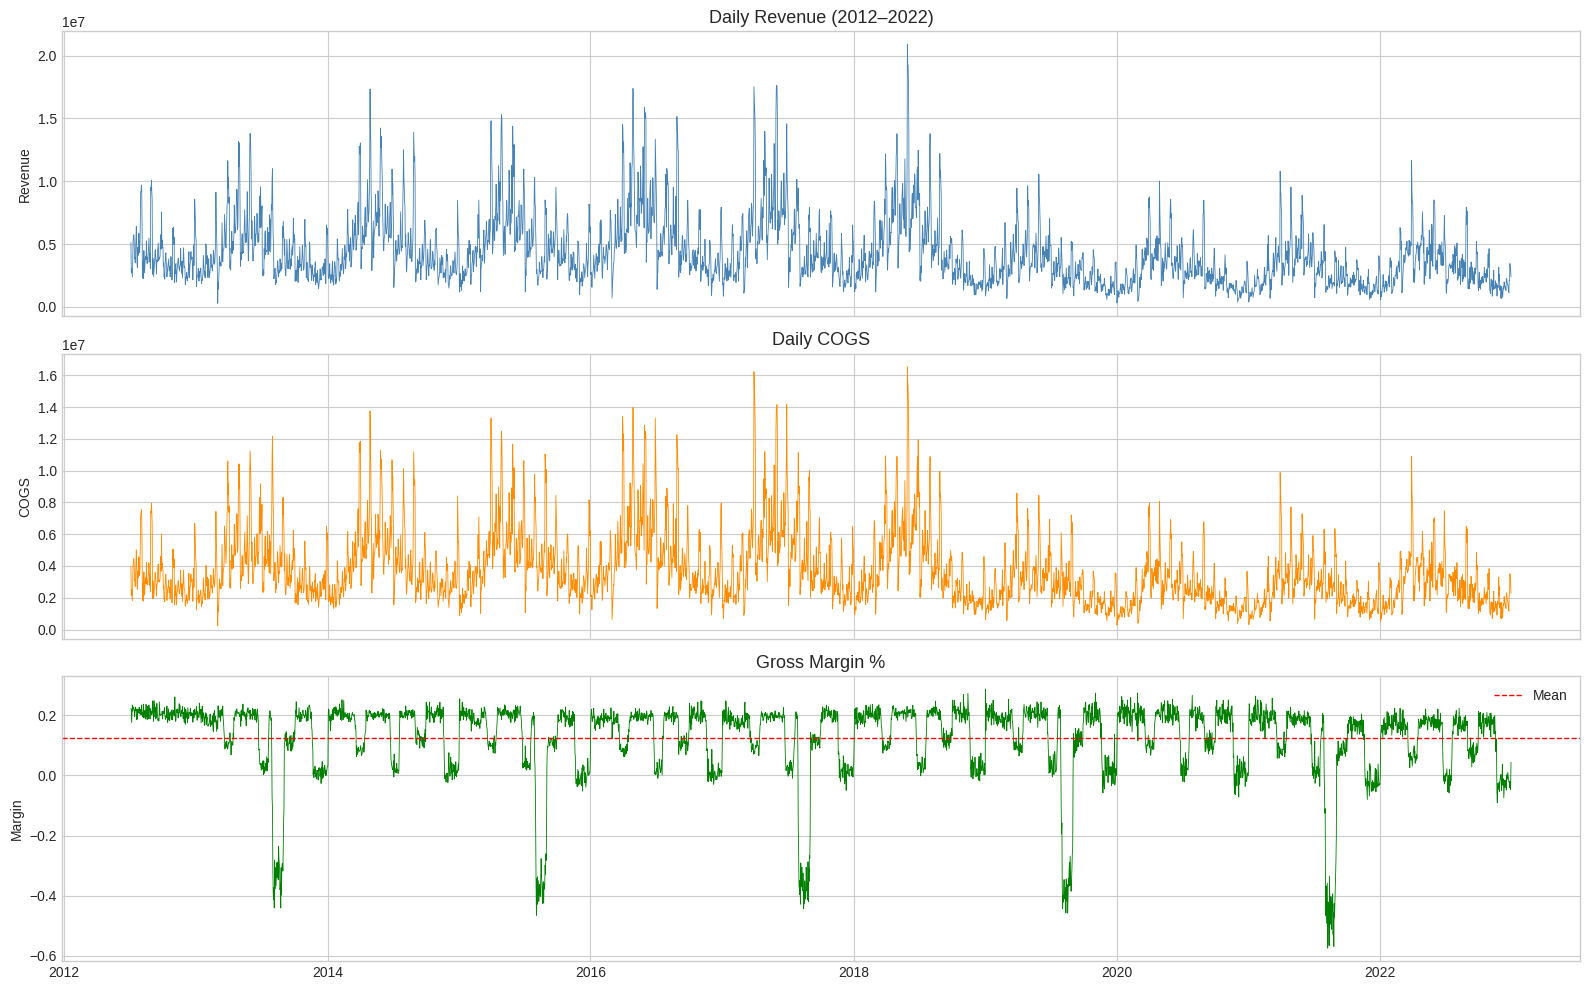

Saved fig_01_revenue_cogs_timeseries.png


In [6]:
# Cell 6: Full Revenue & COGS time series
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].plot(sales['Date'], sales['Revenue'], lw=0.6, color='steelblue')
axes[0].set_title('Daily Revenue (2012–2022)', fontsize=13)
axes[0].set_ylabel('Revenue')

axes[1].plot(sales['Date'], sales['COGS'], lw=0.6, color='darkorange')
axes[1].set_title('Daily COGS', fontsize=13)
axes[1].set_ylabel('COGS')

axes[2].plot(sales['Date'], sales['gross_margin'], lw=0.6, color='green')
axes[2].axhline(sales['gross_margin'].mean(), color='red', linestyle='--', lw=1, label='Mean')
axes[2].set_title('Gross Margin %', fontsize=13)
axes[2].set_ylabel('Margin')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_01_revenue_cogs_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_01_revenue_cogs_timeseries.png")


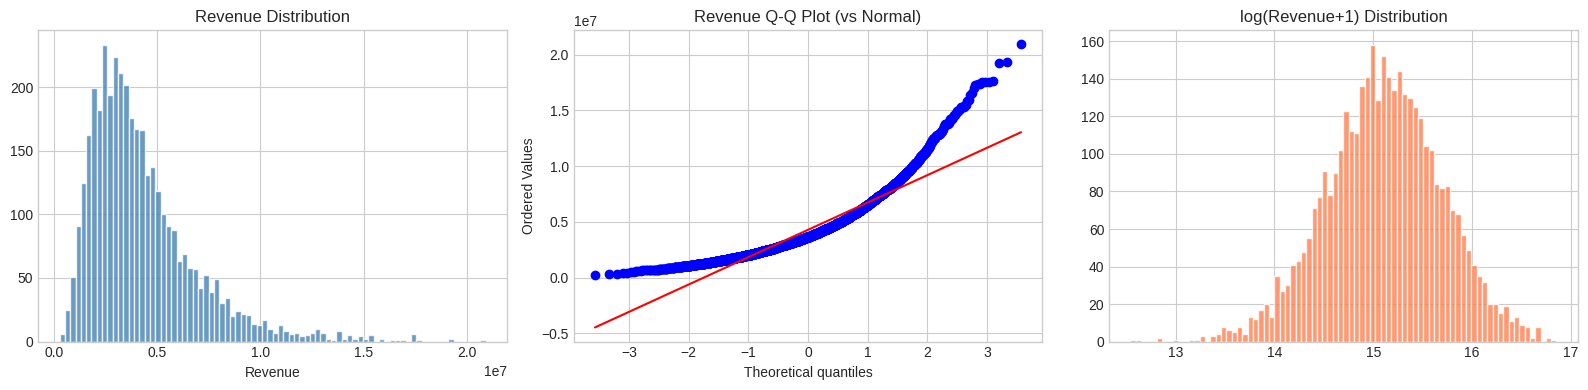

Revenue outliers (3×IQR): 34
Revenue Shapiro-Wilk p-value (normal):     0.000000
log(Revenue) Shapiro-Wilk p-value:          0.000080
Outlier dates:
      Date       Revenue
2014-04-29 17347427.2700
2014-05-28 14237002.3300
2015-03-30 14251354.0400
2015-03-31 14813965.3400
2015-04-28 14371525.0100
2015-04-29 15294818.2200
2015-04-30 14911130.6400
2015-05-30 14386454.2700
2016-03-30 14545392.6400
2016-03-31 14231299.7300
2016-04-27 16379722.5300
2016-04-28 17388183.1900
2016-04-29 16966030.5000
2016-05-30 15902645.0600
2016-05-31 15273734.6200
2016-06-01 15027967.4800
2016-06-02 15450407.8100
2016-06-03 14905219.2300
2016-08-28 15158669.1800
2016-08-29 14043471.1000
2017-03-30 17516038.8200
2017-03-31 16556662.0300
2017-04-01 15808755.6100
2017-04-02 14750037.6500
2017-05-30 15437626.2400
2017-05-31 17314841.8600
2017-06-01 17639270.8800
2017-06-02 17528852.8800
2017-06-03 15308256.1400
2017-06-29 14575854.6700
2018-05-30 20905271.3500
2018-05-31 19289944.1200
2018-06-01 19245165.7800
2

In [7]:
# Cell 7: Revenue Distribution & Outliers
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(sales['Revenue'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Revenue Distribution')
axes[0].set_xlabel('Revenue')

stats.probplot(sales['Revenue'], plot=axes[1])
axes[1].set_title('Revenue Q-Q Plot (vs Normal)')

axes[2].hist(np.log1p(sales['Revenue']), bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[2].set_title('log(Revenue+1) Distribution')

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_02_revenue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Outlier detection via 3×IQR
Q1, Q3 = sales['Revenue'].quantile([0.25, 0.75])
IQR = Q3 - Q1
rev_outliers = sales[(sales['Revenue'] < Q1 - 3*IQR) | (sales['Revenue'] > Q3 + 3*IQR)]

# Normality test on sample
sample = sales['Revenue'].sample(min(5000, len(sales)), random_state=42)
_, p_normal    = stats.shapiro(sample)
_, p_lognormal = stats.shapiro(np.log1p(sample))

print(f"Revenue outliers (3×IQR): {len(rev_outliers)}")
print(f"Revenue Shapiro-Wilk p-value (normal):     {p_normal:.6f}")
print(f"log(Revenue) Shapiro-Wilk p-value:          {p_lognormal:.6f}")
print("Outlier dates:")
print(rev_outliers[['Date','Revenue']].to_string(index=False))

findings['outliers'] = {
    "revenue_outliers_3iqr": int(len(rev_outliers)),
    "outlier_dates": rev_outliers['Date'].dt.strftime('%Y-%m-%d').tolist(),
    "shapiro_wilk_revenue_p":     float(p_normal),
    "shapiro_wilk_log_revenue_p": float(p_lognormal),
    "distribution_recommendation": "log-normal" if p_lognormal > p_normal else "normal"
}


## Section 3: Time Series Decomposition & Stationarity

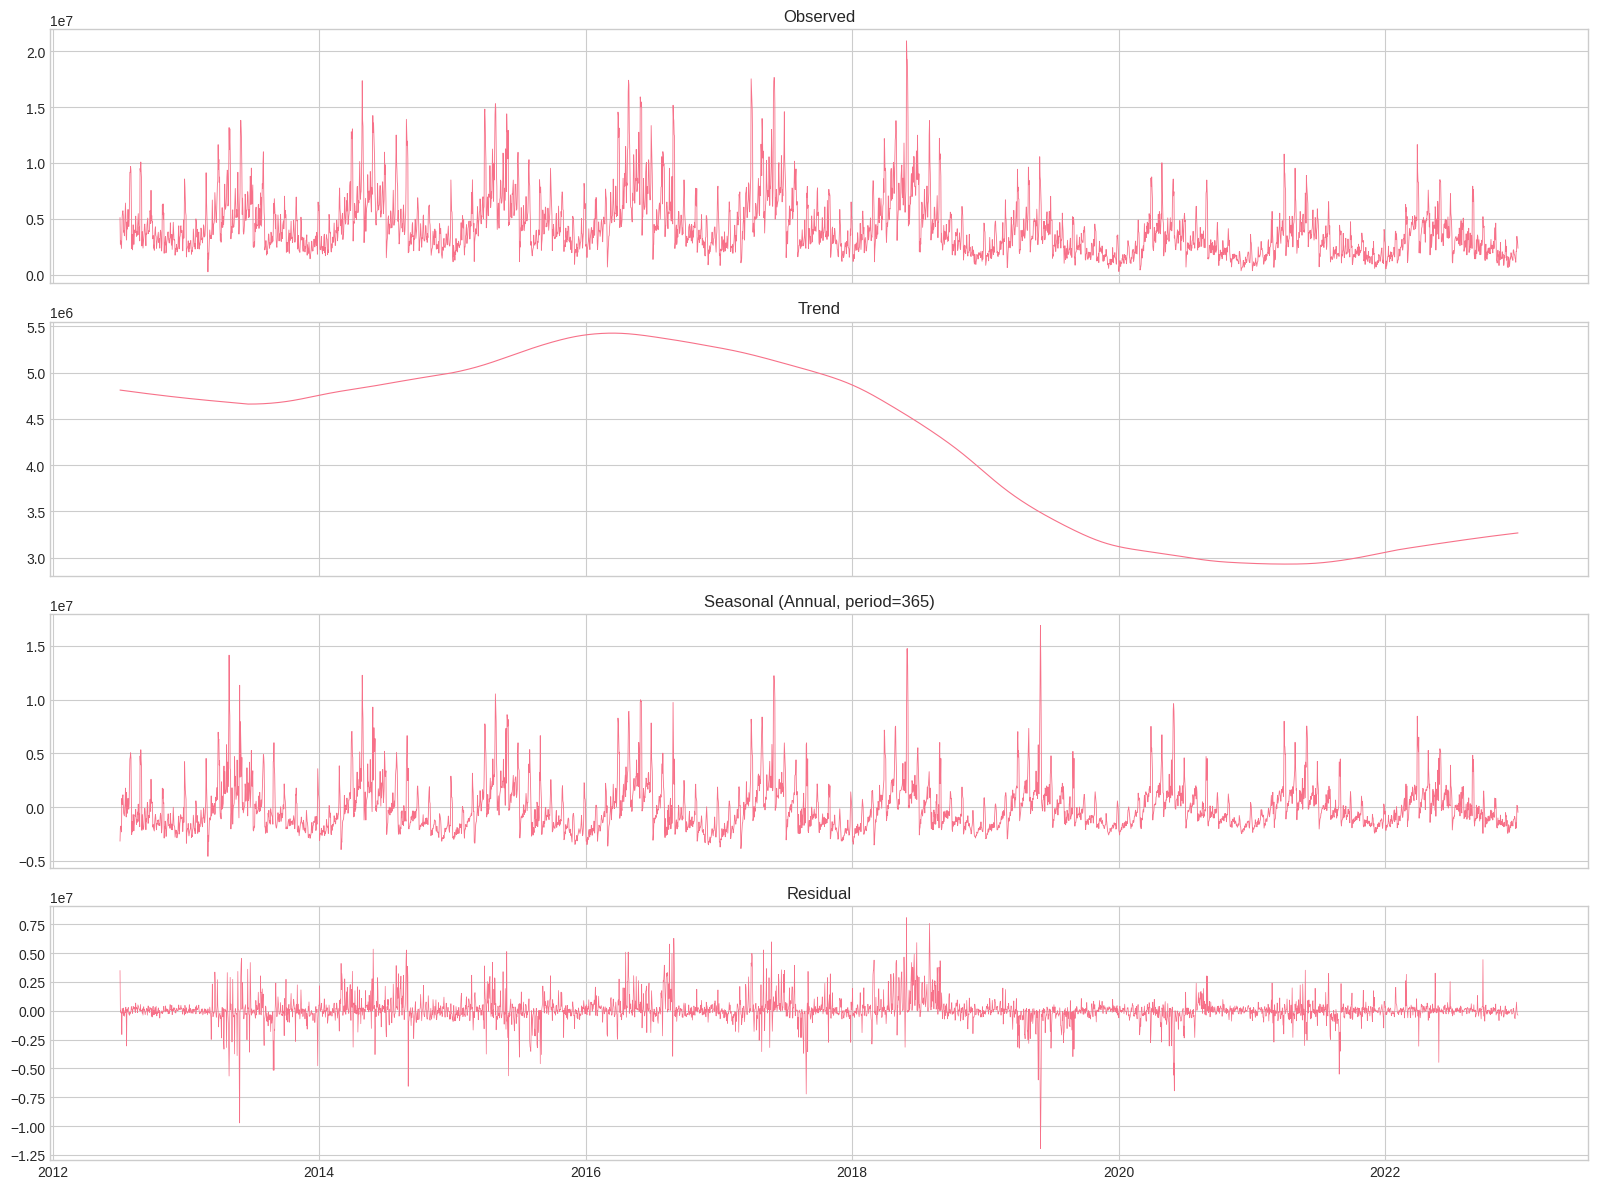

Seasonality Strength Fs: 0.7800  (>0.6 = strong)
Trend Strength Ft:       0.4574  (>0.6 = strong)


In [8]:
# Cell 8: STL Decomposition (Revenue)
stl = STL(sales['Revenue'], period=365, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
axes[0].plot(sales['Date'], result.observed, lw=0.6);  axes[0].set_title('Observed')
axes[1].plot(sales['Date'], result.trend,    lw=0.8);  axes[1].set_title('Trend')
axes[2].plot(sales['Date'], result.seasonal, lw=0.6);  axes[2].set_title('Seasonal (Annual, period=365)')
axes[3].plot(sales['Date'], result.resid,    lw=0.5);  axes[3].set_title('Residual')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_03_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Seasonality & trend strength (Hyndman 2011)
var_resid      = np.var(result.resid)
var_seas_plus  = np.var(result.seasonal + result.resid)
var_trend_plus = np.var(result.trend   + result.resid)
Fs = max(0, 1 - var_resid / var_seas_plus)
Ft = max(0, 1 - var_resid / var_trend_plus)

print(f"Seasonality Strength Fs: {Fs:.4f}  (>0.6 = strong)")
print(f"Trend Strength Ft:       {Ft:.4f}  (>0.6 = strong)")

findings['seasonality'] = {
    "stl_period": 365,
    "seasonality_strength_Fs": round(Fs, 4),
    "trend_strength_Ft":       round(Ft, 4),
    "strong_seasonality": bool(Fs > 0.6),
    "strong_trend":       bool(Ft > 0.6)
}


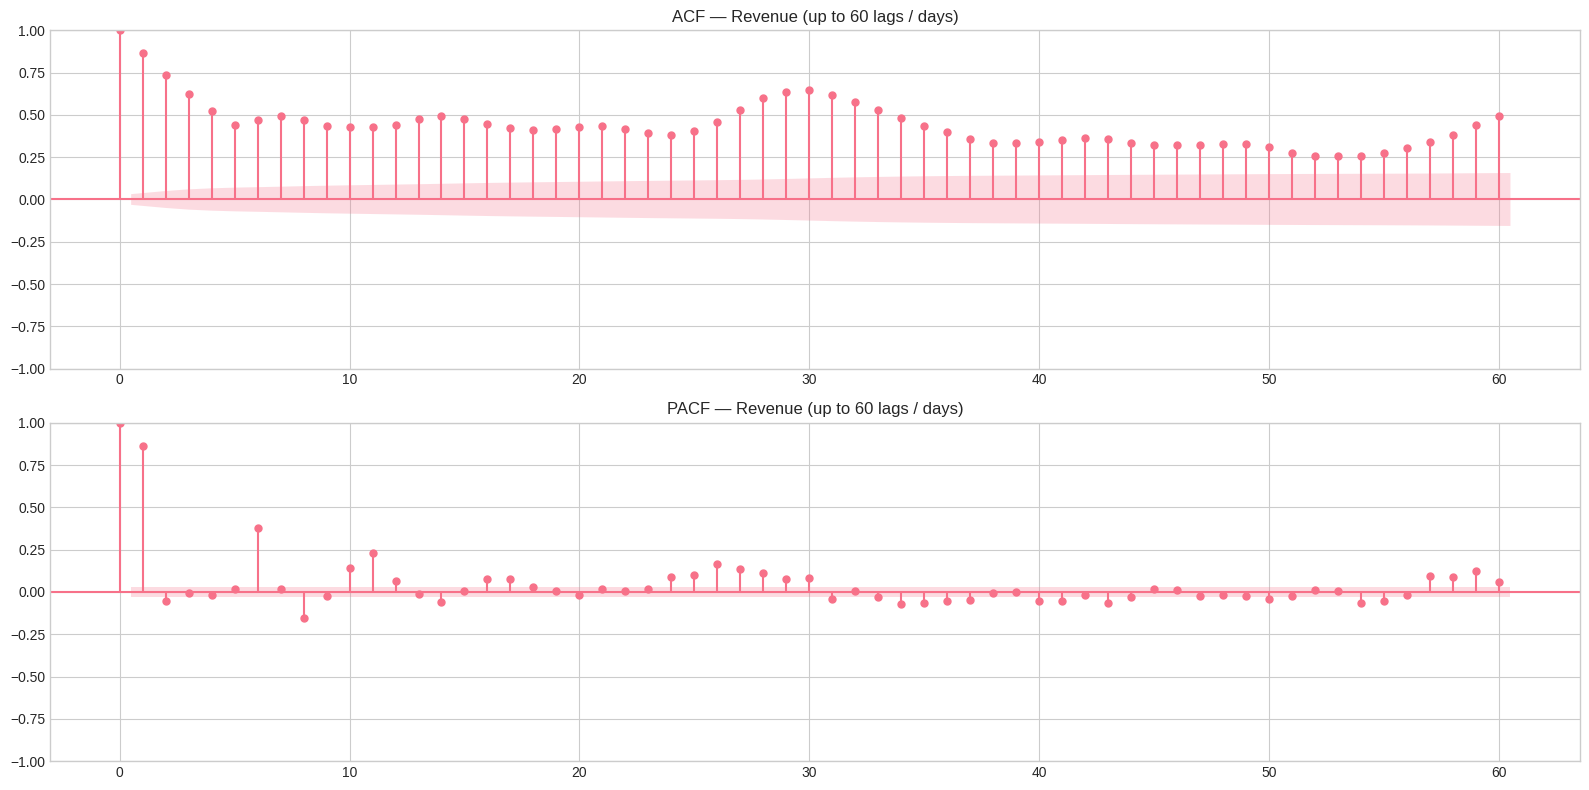

95% confidence threshold: 0.0317
Significant ACF lags:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Significant PACF lags: [1, 2, 6, 8, 10, 11, 12, 14, 16, 17, 18, 24, 25, 26, 27, 28, 29, 30, 31, 34]


In [9]:
# Cell 9: ACF & PACF (Revenue)
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
plot_acf( sales['Revenue'], lags=60, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF — Revenue (up to 60 lags / days)')
plot_pacf(sales['Revenue'], lags=60, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF — Revenue (up to 60 lags / days)')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_04_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

acf_vals  = acf( sales['Revenue'], nlags=60, fft=True)
pacf_vals = pacf(sales['Revenue'], nlags=60, method='ywm')
conf = 1.96 / np.sqrt(len(sales))
sig_acf_lags  = [i for i, v in enumerate(acf_vals[1:],  1) if abs(v) > conf]
sig_pacf_lags = [i for i, v in enumerate(pacf_vals[1:], 1) if abs(v) > conf]

print(f"95% confidence threshold: {conf:.4f}")
print(f"Significant ACF lags:  {sig_acf_lags[:20]}")
print(f"Significant PACF lags: {sig_pacf_lags[:20]}")

findings['autocorrelation'] = {
    "significant_acf_lags":  sig_acf_lags[:20],
    "significant_pacf_lags": sig_pacf_lags[:20],
    "lag_1_acf":  round(float(acf_vals[1]),  4),
    "lag_7_acf":  round(float(acf_vals[7]),  4),
    "lag_30_acf": round(float(acf_vals[30]), 4),
    "lag_52_acf": round(float(acf_vals[52]), 4) if len(acf_vals) > 52 else None,
}


In [10]:
# Cell 10: Stationarity Tests (ADF + KPSS)
rev_series = sales['Revenue'].dropna()

# ADF: H0=unit root (non-stationary). Reject H0 → stationary
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(rev_series, autolag='AIC')

# KPSS: H0=stationary. Reject H0 → non-stationary
kpss_stat, kpss_p, _, kpss_crit = kpss(rev_series, regression='ct', nlags='auto')

print("=== ADF Test (H0: unit root / non-stationary) ===")
print(f"  Statistic: {adf_stat:.4f}  p-value: {adf_p:.6f}")
print(f"  Critical values: {adf_crit}")
print(f"  → {'STATIONARY (reject H0)' if adf_p < 0.05 else 'NON-STATIONARY (fail to reject H0)'}")

print("\n=== KPSS Test (H0: stationary) ===")
print(f"  Statistic: {kpss_stat:.4f}  p-value: {kpss_p:.6f}")
print(f"  Critical values: {kpss_crit}")
print(f"  → {'NON-STATIONARY (reject H0)' if kpss_p < 0.05 else 'STATIONARY (fail to reject H0)'}")

# First-differenced series
diff1 = rev_series.diff().dropna()
adf_d1_stat, adf_d1_p, _, _, _, _ = adfuller(diff1, autolag='AIC')
print(f"\n=== ADF on 1st-differenced Revenue ===")
print(f"  p-value: {adf_d1_p:.6f}  → {'STATIONARY' if adf_d1_p < 0.05 else 'STILL NON-STATIONARY'}")

# Log transform + differenced
log_diff1 = np.log1p(rev_series).diff().dropna()
adf_log_d1_stat, adf_log_d1_p, _, _, _, _ = adfuller(log_diff1, autolag='AIC')
print(f"\n=== ADF on log(Revenue) 1st-differenced ===")
print(f"  p-value: {adf_log_d1_p:.6f}  → {'STATIONARY' if adf_log_d1_p < 0.05 else 'STILL NON-STATIONARY'}")

findings['stationarity'] = {
    "adf":  {"statistic": round(adf_stat,  4), "p_value": round(adf_p,  6), "stationary_at_05": bool(adf_p  < 0.05)},
    "kpss": {"statistic": round(kpss_stat, 4), "p_value": round(kpss_p, 6), "stationary_at_05": bool(kpss_p >= 0.05)},
    "adf_after_diff1":     {"p_value": round(adf_d1_p,    6), "stationary": bool(adf_d1_p    < 0.05)},
    "adf_log_after_diff1": {"p_value": round(adf_log_d1_p,6), "stationary": bool(adf_log_d1_p< 0.05)},
    "differencing_needed": not (bool(adf_p < 0.05) and bool(kpss_p >= 0.05))
}


=== ADF Test (H0: unit root / non-stationary) ===
  Statistic: -2.5250  p-value: 0.109499
  Critical values: {'1%': np.float64(-3.4320711258652885), '5%': np.float64(-2.862300498788623), '10%': np.float64(-2.5671748234670364)}
  → NON-STATIONARY (fail to reject H0)

=== KPSS Test (H0: stationary) ===
  Statistic: 0.3757  p-value: 0.010000
  Critical values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}
  → NON-STATIONARY (reject H0)

=== ADF on 1st-differenced Revenue ===
  p-value: 0.000000  → STATIONARY



=== ADF on log(Revenue) 1st-differenced ===
  p-value: 0.000000  → STATIONARY


## Section 4: Temporal Patterns & Vietnamese Holiday Analysis

In [11]:
# Cell 11: Calendar Features
sales['year']    = sales['Date'].dt.year
sales['month']   = sales['Date'].dt.month
sales['quarter'] = sales['Date'].dt.quarter
sales['dow']     = sales['Date'].dt.dayofweek   # 0=Mon, 6=Sun
sales['dom']     = sales['Date'].dt.day
sales['week']    = sales['Date'].dt.isocalendar().week.astype(int)
sales['doy']     = sales['Date'].dt.dayofyear

# Vietnamese public holidays (2012–2022)
vn_holidays = set()
for year in range(2012, 2023):
    for d in hol.Vietnam(years=year).keys():
        vn_holidays.add(d)
sales['is_holiday'] = sales['Date'].dt.date.isin(vn_holidays).astype(int)

# Tet window: proper lunar calendar day-1 dates; window = 7 days before through 14 days after
TET_DATES = {
    2012: pd.Timestamp("2012-01-23"), 2013: pd.Timestamp("2013-02-10"),
    2014: pd.Timestamp("2014-01-31"), 2015: pd.Timestamp("2015-02-19"),
    2016: pd.Timestamp("2016-02-08"), 2017: pd.Timestamp("2017-01-28"),
    2018: pd.Timestamp("2018-02-16"), 2019: pd.Timestamp("2019-02-05"),
    2020: pd.Timestamp("2020-01-25"), 2021: pd.Timestamp("2021-02-12"),
    2022: pd.Timestamp("2022-02-01"),
}
days_to_tet = np.full(len(sales), 999, dtype=np.int32)
for _y, _t in TET_DATES.items():
    _delta = (_t - sales['Date']).dt.days.values
    _closer = np.abs(_delta) < np.abs(days_to_tet)
    days_to_tet = np.where(_closer, _delta, days_to_tet)
sales['days_to_tet']  = days_to_tet
sales['is_tet_window'] = ((days_to_tet >= -7) & (days_to_tet <= 14)).astype(int)
sales['is_tet_holiday'] = ((sales['is_holiday'] == 1) & (sales['is_tet_window'] == 1)).astype(int)

print(f"Holiday days in training set: {sales['is_holiday'].sum()}")
print(f"Tet-window days (lunar -7..+14): {sales['is_tet_window'].sum()}")
print(f"  of which are public holidays: {sales['is_tet_holiday'].sum()}")
print(f"Non-Tet public holidays: {(sales['is_holiday'] - sales['is_tet_holiday']).sum()}")


Holiday days in training set: 140
Tet-window days (lunar -7..+14): 220
  of which are public holidays: 66
Non-Tet public holidays: 74


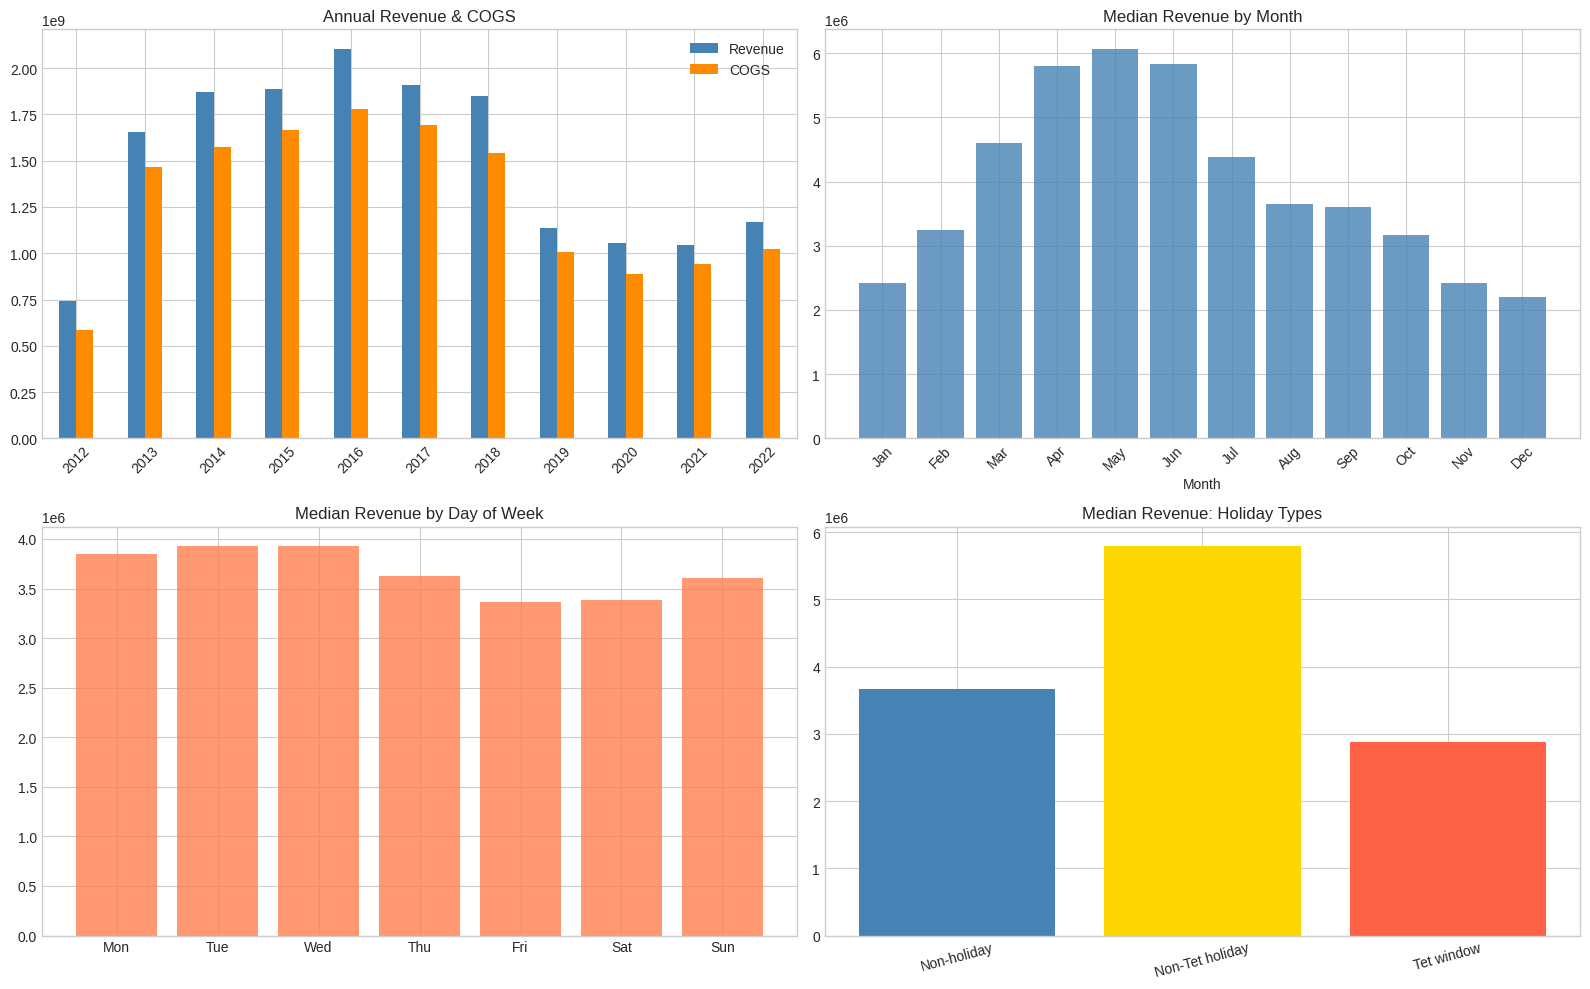

Tet-window lift (DOY-adjusted):         +1.5%
Non-Tet public holiday lift (DOY-adj):  -3.5%
YoY Revenue growth: mean=10.2%, std=42.6%


In [12]:
# Cell 12: Yearly, Monthly, DOW & Holiday Patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Annual totals
annual = sales.groupby('year')[['Revenue', 'COGS']].sum()
annual.plot(kind='bar', ax=axes[0][0], color=['steelblue','darkorange'])
axes[0][0].set_title('Annual Revenue & COGS')
axes[0][0].set_xlabel('')
axes[0][0].tick_params(axis='x', rotation=45)

# Monthly medians
monthly = sales.groupby('month')['Revenue'].median()
axes[0][1].bar(monthly.index, monthly.values, color='steelblue', alpha=0.8)
axes[0][1].set_title('Median Revenue by Month')
axes[0][1].set_xlabel('Month')
axes[0][1].set_xticks(range(1,13))
axes[0][1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

# Day-of-week medians
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow = sales.groupby('dow')['Revenue'].median()
axes[1][0].bar(range(7), dow.values, color='coral', alpha=0.8)
axes[1][0].set_title('Median Revenue by Day of Week')
axes[1][0].set_xticks(range(7))
axes[1][0].set_xticklabels(dow_labels)

# Holiday vs non-holiday — split into Tet-window, non-Tet holiday, and baseline
_hol_groups = {
    'Non-holiday':      sales[(sales['is_holiday']==0) & (sales['is_tet_window']==0)]['Revenue'].median(),
    'Non-Tet holiday':  sales[(sales['is_holiday']==1) & (sales['is_tet_window']==0)]['Revenue'].median(),
    'Tet window':       sales[sales['is_tet_window']==1]['Revenue'].median(),
}
axes[1][1].bar(_hol_groups.keys(), _hol_groups.values(),
               color=['steelblue','gold','tomato'])
axes[1][1].set_title('Median Revenue: Holiday Types')
axes[1][1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_05_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# DOY-adjusted lifts: controls for the Jan-Feb seasonal slowdown that would
# otherwise inflate/deflate the Tet effect. Each day is normalised by the
# median revenue for that calendar day-of-year across all training years.
doy_median = sales.groupby('doy')['Revenue'].transform('median')
sales['_rev_ratio'] = sales['Revenue'] / doy_median

tet_lift      = sales[sales['is_tet_window']==1]['_rev_ratio'].mean() - 1
nontet_hol_mask = (sales['is_holiday']==1) & (sales['is_tet_window']==0)
nontet_hol_lift = sales[nontet_hol_mask]['_rev_ratio'].mean() - 1
yoy = annual['Revenue'].pct_change().dropna()

print(f"Tet-window lift (DOY-adjusted):         {tet_lift*100:+.1f}%")
print(f"Non-Tet public holiday lift (DOY-adj):  {nontet_hol_lift*100:+.1f}%")
print(f"YoY Revenue growth: mean={yoy.mean()*100:.1f}%, std={yoy.std()*100:.1f}%")

findings['temporal_patterns'] = {
    "annual_revenue":         {int(k): round(float(v),2) for k,v in annual['Revenue'].to_dict().items()},
    "annual_cogs":            {int(k): round(float(v),2) for k,v in annual['COGS'].to_dict().items()},
    "yoy_growth_mean":        round(float(yoy.mean()), 4),
    "yoy_growth_std":         round(float(yoy.std()),  4),
    "monthly_median_revenue": {int(k): round(float(v),2) for k,v in monthly.to_dict().items()},
    "dow_median_revenue":     {dow_labels[k]: round(float(v),2) for k,v in dow.to_dict().items()},
    "tet_lift_pct":           round(tet_lift * 100, 2),
    "holiday_lift_pct":       round(nontet_hol_lift * 100, 2),
    "holiday_days_count":     int(sales['is_holiday'].sum()),
    "tet_season_days":        int(sales['is_tet_window'].sum())
}


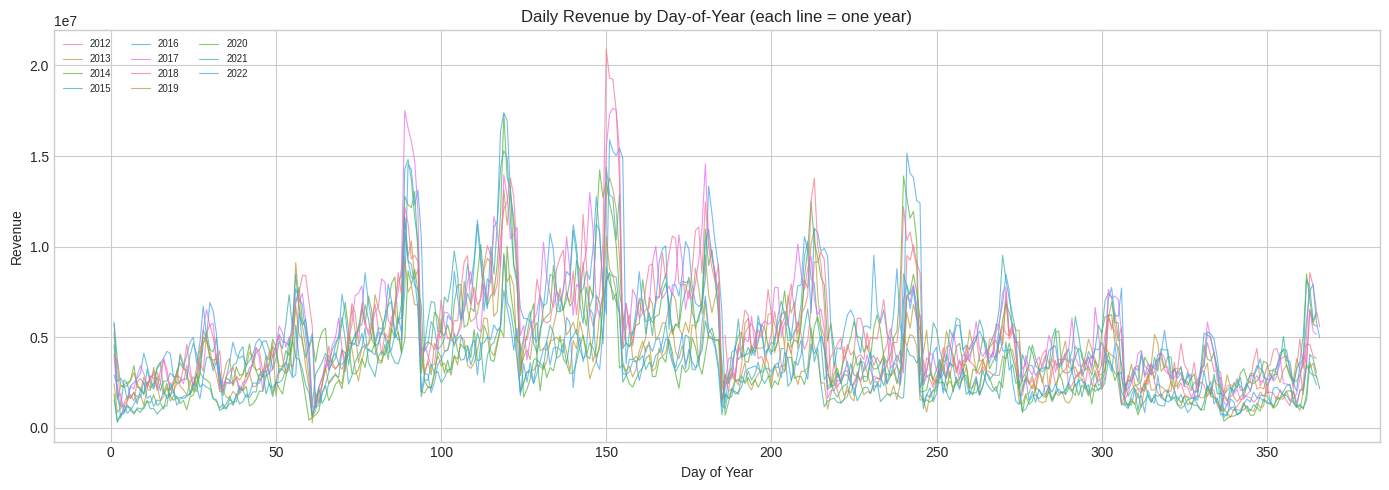

YoY overlay saved.


In [13]:
# Cell 12b: Year-over-year overlaid plot (seasonality check)
fig, ax = plt.subplots(figsize=(14, 5))
for year in sorted(sales['year'].unique()):
    yr_data = sales[sales['year']==year].copy()
    ax.plot(yr_data['doy'], yr_data['Revenue'], lw=0.8, alpha=0.7, label=str(year))
ax.set_title('Daily Revenue by Day-of-Year (each line = one year)')
ax.set_xlabel('Day of Year')
ax.set_ylabel('Revenue')
ax.legend(loc='upper left', fontsize=7, ncol=3)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_05b_yoy_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("YoY overlay saved.")


## Section 5: Aggregate Large CSVs → Parquet

In [14]:
# Cell 13: Aggregate orders to daily
print("Aggregating orders.csv to daily...")
daily_orders = orders.groupby('order_date').agg(
    n_orders          = ('order_id',        'count'),
    n_customers       = ('customer_id',     'nunique'),
    n_delivered       = ('order_status',    lambda x: (x=='delivered').sum()),
    n_cancelled       = ('order_status',    lambda x: (x=='cancelled').sum()),
    n_returned        = ('order_status',    lambda x: (x=='returned').sum()),
    mobile_share      = ('device_type',     lambda x: (x=='mobile').mean()),
    credit_card_share = ('payment_method',  lambda x: (x=='credit_card').mean()),
).reset_index().rename(columns={'order_date': 'date'})

daily_orders.to_parquet(PROC_DIR + 'daily_orders.parquet', index=False)
print(f"Saved daily_orders.parquet: {daily_orders.shape}")
daily_orders.head()


Aggregating orders.csv to daily...


Saved daily_orders.parquet: (3833, 8)


,date,n_orders,n_customers,n_delivered,n_cancelled,n_returned,mobile_share,credit_card_share
0,2012-07-04,162,161,134,9,11,0.4259,0.5247
1,2012-07-05,97,97,81,9,5,0.3918,0.4845
2,2012-07-06,93,93,69,11,7,0.4516,0.6452
3,2012-07-07,73,73,55,8,6,0.4658,0.5479
4,2012-07-08,88,87,67,5,8,0.5114,0.5682


In [15]:
# Cell 14: Aggregate order_items to daily
print("Aggregating order_items.csv to daily...")
items_with_date = order_items.merge(
    orders[['order_id','order_date']], on='order_id', how='left'
)
daily_items = items_with_date.groupby('order_date').agg(
    gross_revenue     = ('unit_price',      lambda x: (x * items_with_date.loc[x.index,'quantity']).sum()),
    total_discount    = ('discount_amount', 'sum'),
    n_items           = ('product_id',      'count'),
    n_unique_products = ('product_id',      'nunique'),
    avg_unit_price    = ('unit_price',      'mean'),
    promo_items       = ('promo_id',        lambda x: x.notna().sum()),
).reset_index().rename(columns={'order_date': 'date'})

daily_items['net_revenue_from_items'] = daily_items['gross_revenue'] - daily_items['total_discount']
daily_items['promo_attach_rate']      = daily_items['promo_items'] / daily_items['n_items']

daily_items.to_parquet(PROC_DIR + 'daily_items.parquet', index=False)
print(f"Saved daily_items.parquet: {daily_items.shape}")
daily_items.head()


Aggregating order_items.csv to daily...


Saved daily_items.parquet: (3833, 9)


,date,gross_revenue,total_discount,n_items,n_unique_products,avg_unit_price,promo_items,net_revenue_from_items,promo_attach_rate
0,2012-07-04,5123547.9400,0.0000,174,93,6394.1236,0,5123547.9400,0.0000
1,2012-07-05,2751773.4500,0.0000,103,65,6744.2831,0,2751773.4500,0.0000
2,2012-07-06,3054029.4200,0.0000,99,73,6793.8196,0,3054029.4200,0.0000
3,2012-07-07,2667930.9400,0.0000,75,50,7475.4785,0,2667930.9400,0.0000
4,2012-07-08,2360851.9000,0.0000,94,62,5766.6820,0,2360851.9000,0.0000


In [16]:
# Cell 15: Aggregate returns and shipments to daily
print("Aggregating returns.csv...")
returns_with_date = returns.merge(
    orders[['order_id','order_date']], on='order_id', how='left'
)
daily_returns = returns_with_date.groupby('order_date').agg(
    n_returns    = ('return_id',       'count'),
    total_refund = ('refund_amount',   'sum'),
    return_qty   = ('return_quantity', 'sum'),
).reset_index().rename(columns={'order_date': 'date'})

print("Aggregating shipments.csv...")
shipments_with_date = shipments.merge(
    orders[['order_id','order_date']], on='order_id', how='left'
)
daily_shipments = shipments_with_date.groupby('order_date').agg(
    n_shipped      = ('order_id',     'count'),
    total_ship_fee = ('shipping_fee', 'sum'),
    avg_ship_fee   = ('shipping_fee', 'mean'),
).reset_index().rename(columns={'order_date': 'date'})

daily_returns.to_parquet(PROC_DIR  + 'daily_returns.parquet',  index=False)
daily_shipments.to_parquet(PROC_DIR + 'daily_shipments.parquet', index=False)
print(f"Saved daily_returns.parquet: {daily_returns.shape}")
print(f"Saved daily_shipments.parquet: {daily_shipments.shape}")


Aggregating returns.csv...
Aggregating shipments.csv...
Saved daily_returns.parquet: (3769, 4)
Saved daily_shipments.parquet: (3831, 4)


## Section 6: Revenue Reconciliation (order_items vs sales.csv)

Reconciliation Stats:
  Correlation (items_net vs Revenue):  0.9921
  Mean absolute delta:                 195,567
  Mean delta % of Revenue:             5.17%
  Days with >10% discrepancy:          1106
  Reconciles well (<5% mean delta):    False


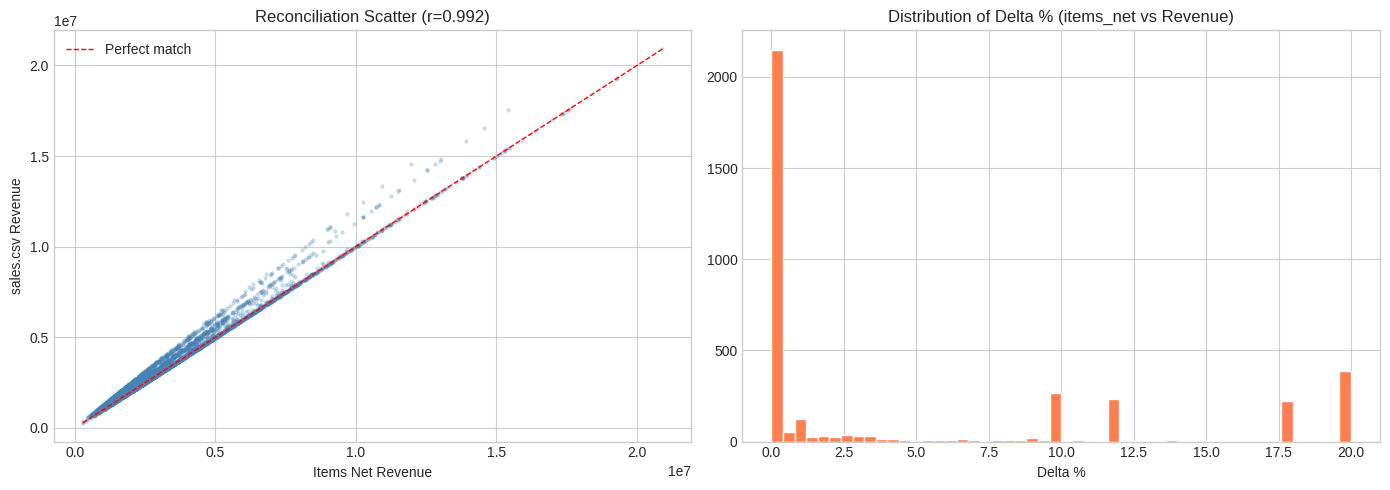

In [17]:
# Cell 16: Revenue Reconciliation
daily_items_loaded = pd.read_parquet(PROC_DIR + 'daily_items.parquet')

recon = sales[['Date','Revenue','COGS']].copy()
recon['date'] = recon['Date']
recon = recon.merge(
    daily_items_loaded[['date','net_revenue_from_items','gross_revenue','total_discount']],
    on='date', how='left'
)
recon['delta_abs'] = (recon['Revenue'] - recon['net_revenue_from_items']).abs()
recon['delta_pct'] = recon['delta_abs'] / recon['Revenue'] * 100

corr_val = float(recon['Revenue'].corr(recon['net_revenue_from_items']))
print("Reconciliation Stats:")
print(f"  Correlation (items_net vs Revenue):  {corr_val:.4f}")
print(f"  Mean absolute delta:                 {recon['delta_abs'].mean():,.0f}")
print(f"  Mean delta % of Revenue:             {recon['delta_pct'].mean():.2f}%")
print(f"  Days with >10% discrepancy:          {(recon['delta_pct'] > 10).sum()}")
print(f"  Reconciles well (<5% mean delta):    {recon['delta_pct'].mean() < 5.0}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(recon['net_revenue_from_items'], recon['Revenue'], alpha=0.2, s=5, color='steelblue')
axes[0].set_xlabel('Items Net Revenue')
axes[0].set_ylabel('sales.csv Revenue')
axes[0].set_title(f'Reconciliation Scatter (r={corr_val:.3f})')
mn = float(min(recon[['Revenue','net_revenue_from_items']].min()))
mx = float(max(recon[['Revenue','net_revenue_from_items']].max()))
axes[0].plot([mn,mx],[mn,mx],'r--',lw=1,label='Perfect match')
axes[0].legend()

axes[1].hist(recon['delta_pct'].dropna(), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Delta % (items_net vs Revenue)')
axes[1].set_xlabel('Delta %')

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_06_reconciliation.png', dpi=150, bbox_inches='tight')
plt.show()

findings['transaction_features']['reconciliation'] = {
    "corr_items_vs_revenue": round(corr_val, 4),
    "mean_delta_pct":        round(float(recon['delta_pct'].mean()), 2),
    "reconciles_well":       bool(recon['delta_pct'].mean() < 5.0)
}


## Section 7: Web Traffic Analysis

> **NOTE:** web_traffic.csv covers 2013-01-01 → 2022-12-31 only. NO web data available for test period 2023-2024.

Web traffic date range: 2013-01-01 → 2022-12-31
Web traffic columns: ['date', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec', 'traffic_source']
                      date   sessions  unique_visitors  page_views  \
count                 3652  3652.0000        3652.0000   3652.0000   
mean   2017-12-31 12:00:00 25041.7681       19031.4044 108615.2245   
min    2013-01-01 00:00:00  7973.0000        6136.0000  30451.0000   
25%    2015-07-02 18:00:00 17099.2500       12915.0000  72982.0000   
50%    2017-12-31 12:00:00 23633.5000       17924.0000 101010.5000   
75%    2020-07-01 06:00:00 31782.7500       24191.7500 138086.0000   
max    2022-12-31 00:00:00 50947.0000       40430.0000 275560.0000   
std                    NaN  9422.6093        7237.9531  44472.0555   

       bounce_rate  avg_session_duration_sec  
count    3652.0000                 3652.0000  
mean        0.0045                  210.2832  
min         0.0032                  100.1000

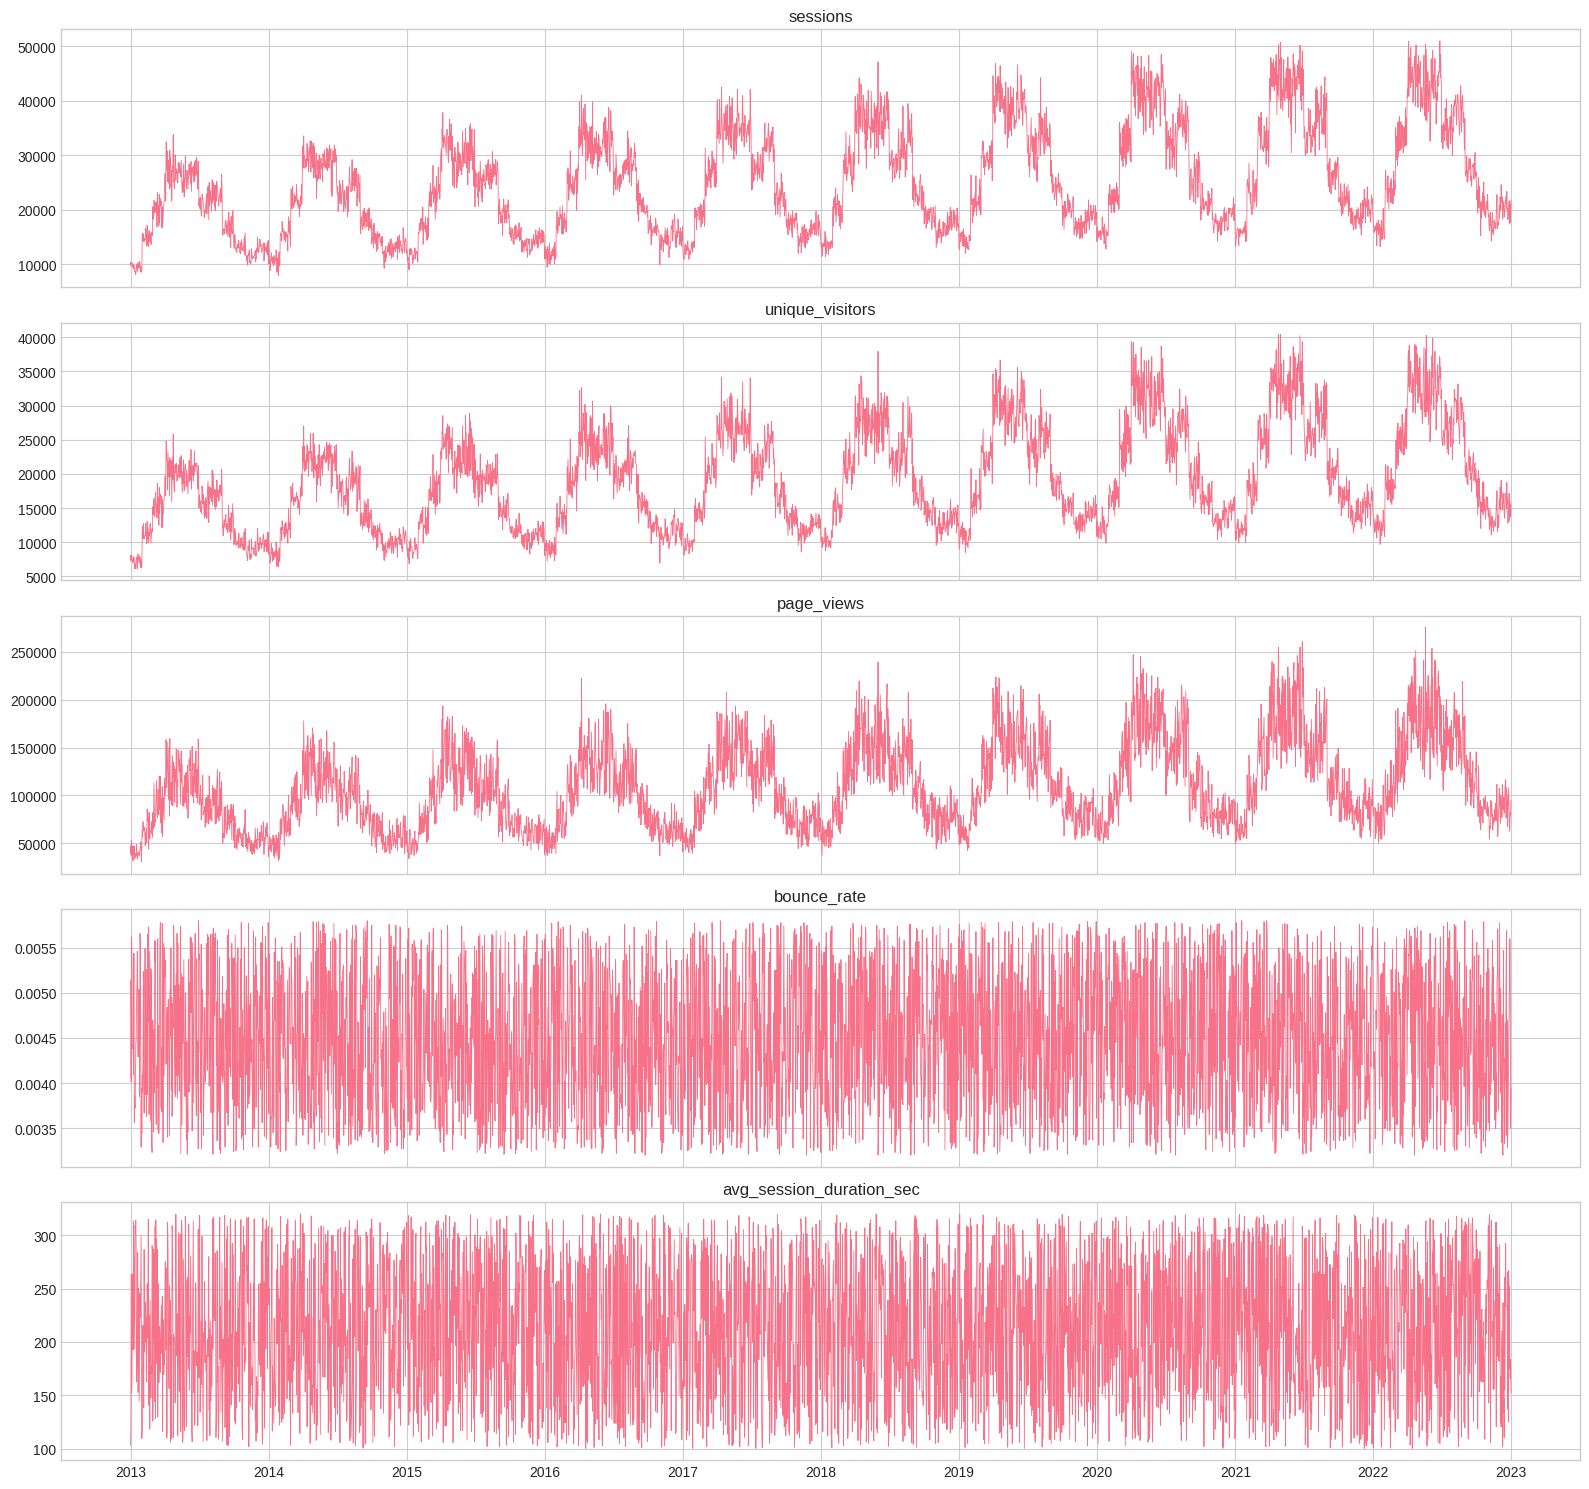

In [18]:
# Cell 17: Web Traffic Analysis
print(f"Web traffic date range: {web['date'].min().date()} → {web['date'].max().date()}")
print(f"Web traffic columns: {list(web.columns)}")
print(web.describe())

web_merged  = sales.merge(web, left_on='Date', right_on='date', how='inner')
print(f"\nOverlapping days (sales ∩ web_traffic): {len(web_merged)}")

numeric_web_cols = web.select_dtypes(include='number').columns.tolist()
print(f"Numeric web columns: {numeric_web_cols}")

corr_rev  = web_merged[numeric_web_cols + ['Revenue']].corr()['Revenue'].drop('Revenue')
corr_cogs = web_merged[numeric_web_cols + ['COGS']].corr()['COGS'].drop('COGS')

print("\nCorrelations with Revenue:")
print(corr_rev.sort_values(ascending=False).to_string())

fig, axes = plt.subplots(len(numeric_web_cols), 1, figsize=(16, 3*len(numeric_web_cols)), sharex=True)
if len(numeric_web_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_web_cols):
    ax.plot(web['date'], web[col], lw=0.6)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_07_web_traffic_trends.png', dpi=150, bbox_inches='tight')
plt.show()

findings['external_availability'] = {
    "web_traffic":  {"date_range": "2013-01-01 to 2022-12-31", "covers_test": False},
    "inventory":    {"date_range": "2012-07-31 to 2022-12-31", "covers_test": False},
    "orders":       {"date_range": "2012-07-04 to 2022-12-31", "covers_test": False},
    "note": "ALL external datasets end 2022-12-31. Test period 2023-01-01 to 2024-07-01 has ZERO external features without additional forecasting."
}
findings['correlation_with_revenue']['web_traffic'] = {
    col: round(float(corr_rev[col]), 4) for col in numeric_web_cols if col in corr_rev.index
}


## Section 8: Transaction & Behavior Analysis

In [19]:
# Cell 19: Load daily parquets and build merged analysis frame
daily_orders_df   = pd.read_parquet(PROC_DIR + 'daily_orders.parquet')
daily_items_df    = pd.read_parquet(PROC_DIR + 'daily_items.parquet')
daily_returns_df  = pd.read_parquet(PROC_DIR + 'daily_returns.parquet')
daily_ships_df    = pd.read_parquet(PROC_DIR + 'daily_shipments.parquet')

daily = sales[['Date','Revenue','COGS']].copy().rename(columns={'Date':'date'})
daily = daily.merge(daily_orders_df,  on='date', how='left')
daily = daily.merge(daily_items_df,   on='date', how='left')
daily = daily.merge(daily_returns_df, on='date', how='left')
daily = daily.merge(daily_ships_df,   on='date', how='left')
daily = daily.merge(web.rename(columns={'date':'date'}), on='date', how='left')

daily['aov']         = daily['net_revenue_from_items'] / daily['n_orders'].replace(0, np.nan)
daily['return_rate'] = daily['n_returns'] / daily['n_orders'].replace(0, np.nan)

print(f"Merged daily frame shape: {daily.shape}")
print(f"Date range: {daily['date'].min().date()} → {daily['date'].max().date()}")
print(f"Columns: {list(daily.columns)}")


Merged daily frame shape: (3833, 32)
Date range: 2012-07-04 → 2022-12-31
Columns: ['date', 'Revenue', 'COGS', 'n_orders', 'n_customers', 'n_delivered', 'n_cancelled', 'n_returned', 'mobile_share', 'credit_card_share', 'gross_revenue', 'total_discount', 'n_items', 'n_unique_products', 'avg_unit_price', 'promo_items', 'net_revenue_from_items', 'promo_attach_rate', 'n_returns', 'total_refund', 'return_qty', 'n_shipped', 'total_ship_fee', 'avg_ship_fee', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec', 'traffic_source', 'aov', 'return_rate']


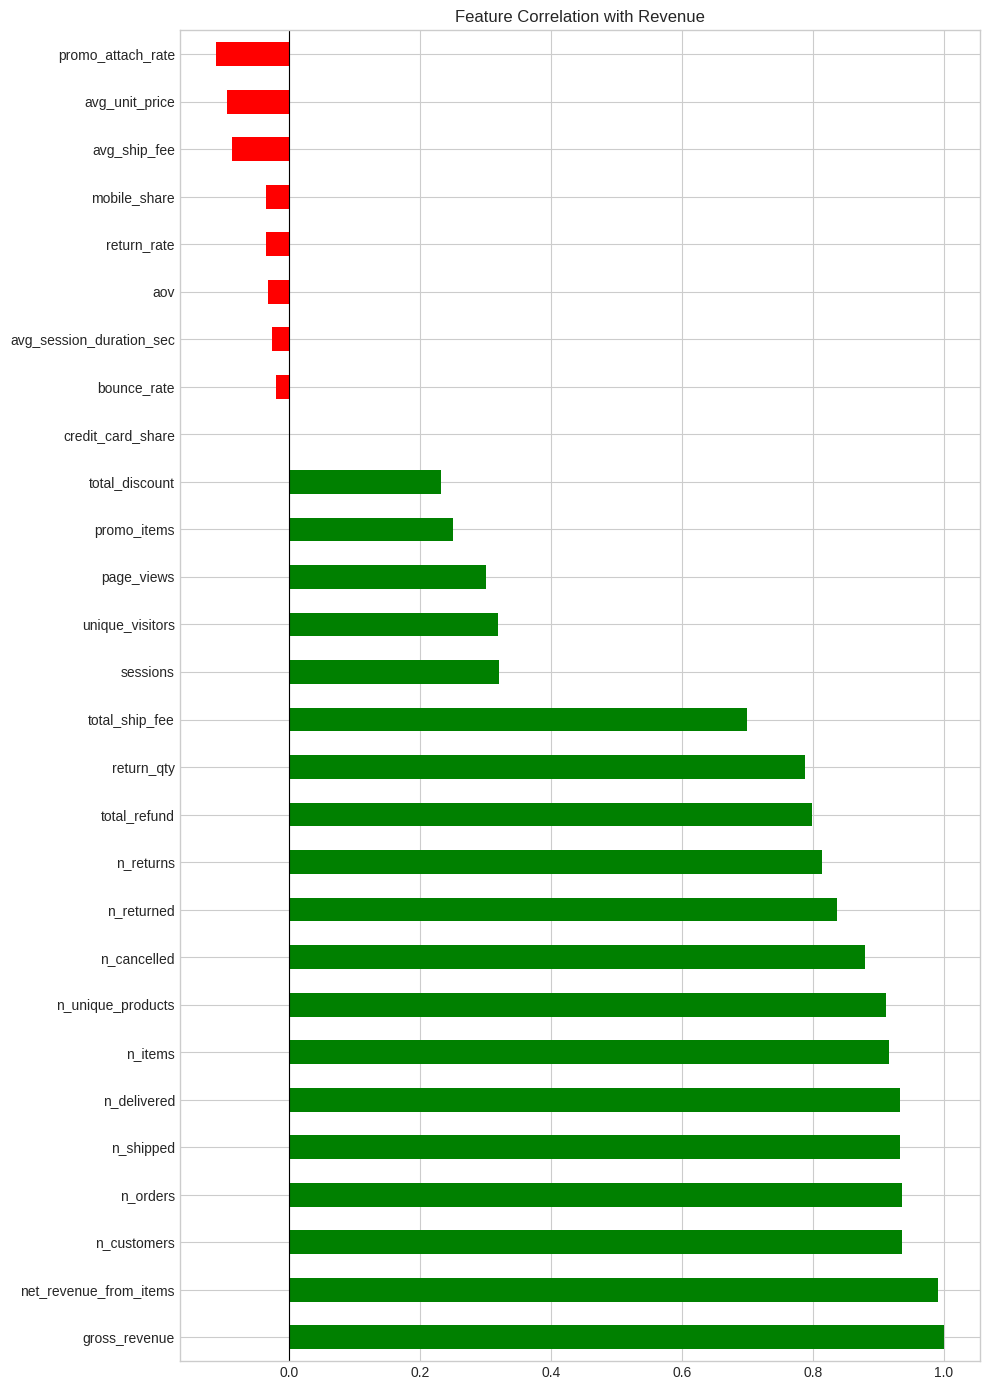

Top positive correlations with Revenue:
gross_revenue            1.0000
net_revenue_from_items   0.9921
n_customers              0.9370
n_orders                 0.9359
n_shipped                0.9340
n_delivered              0.9331
n_items                  0.9159
n_unique_products        0.9113
n_cancelled              0.8794
n_returned               0.8373

Top negative correlations with Revenue:
return_rate         -0.0356
mobile_share        -0.0358
avg_ship_fee        -0.0874
avg_unit_price      -0.0940
promo_attach_rate   -0.1114


In [20]:
# Cell 20: Feature correlation heatmap with Revenue
exclude_cols = ['date','Revenue','COGS']
feature_cols = [c for c in daily.select_dtypes(include='number').columns
                if c not in exclude_cols and daily[c].notna().mean() > 0.5]

corr_rev_series = daily[feature_cols + ['Revenue']].corr()['Revenue'].drop('Revenue').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(5, len(feature_cols)//2)))
colors = ['green' if v > 0 else 'red' for v in corr_rev_series]
corr_rev_series.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Correlation with Revenue')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_08_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top positive correlations with Revenue:")
print(corr_rev_series.head(10).to_string())
print("\nTop negative correlations with Revenue:")
print(corr_rev_series.tail(5).to_string())

findings['correlation_with_revenue']['transaction'] = {
    col: round(float(corr_rev_series[col]), 4)
    for col in feature_cols if col in corr_rev_series.index
}


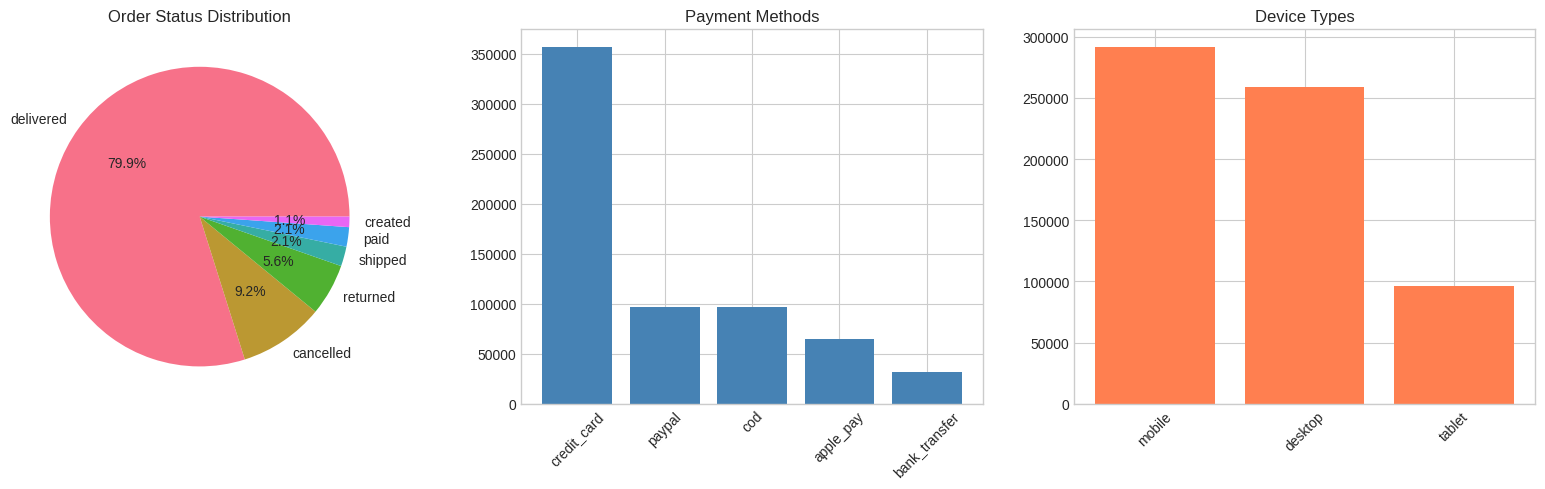

Order status breakdown:
order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275

Return reasons (top 10):
return_reason
wrong_size          13967
defective            8020
not_as_described     7035
changed_mind         6931
late_delivery        3986


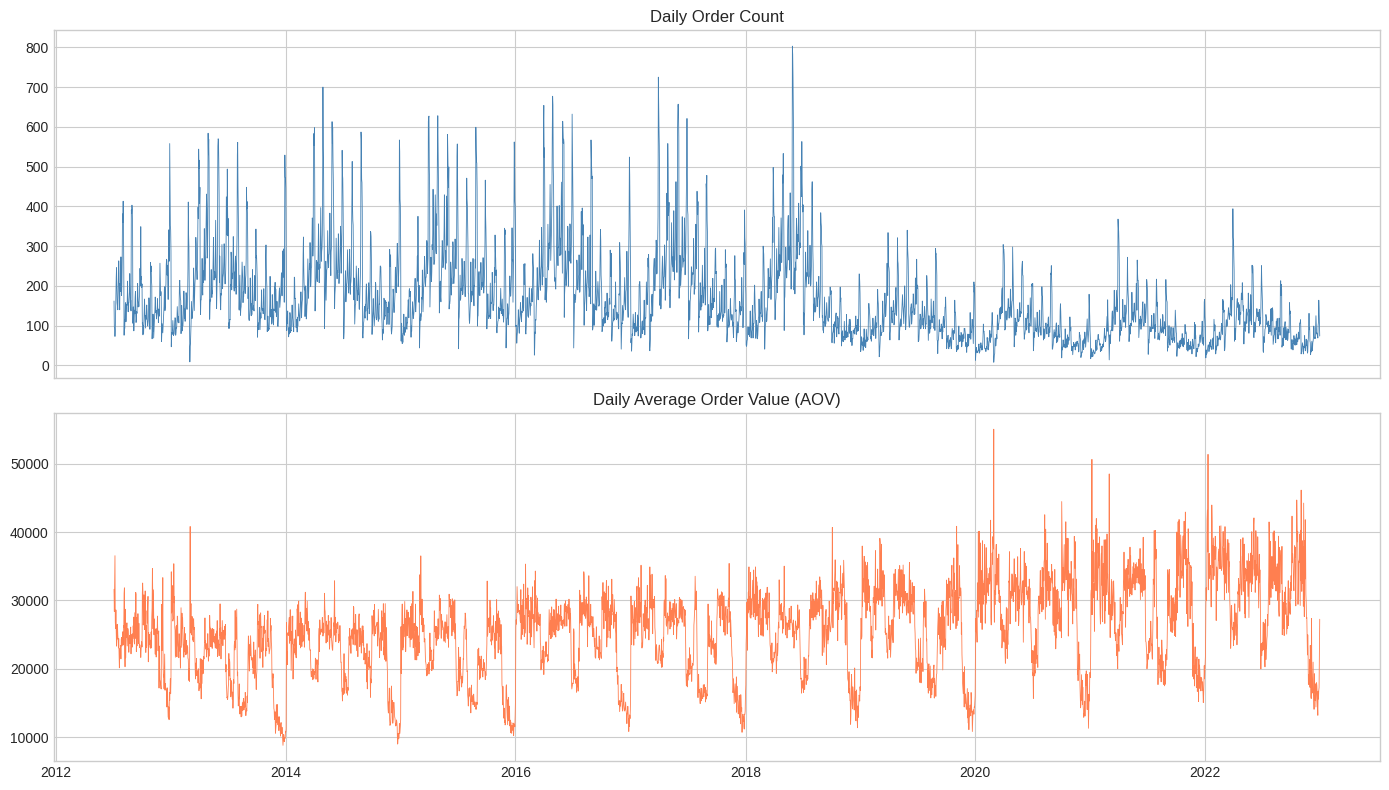

In [21]:
# Cell 21: Categorical distributions (order status, payment, device)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

status_counts = orders['order_status'].value_counts()
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%')
axes[0].set_title('Order Status Distribution')

pay_counts = orders['payment_method'].value_counts()
axes[1].bar(pay_counts.index, pay_counts.values, color='steelblue')
axes[1].set_title('Payment Methods')
axes[1].tick_params(axis='x', rotation=45)

dev_counts = orders['device_type'].value_counts()
axes[2].bar(dev_counts.index, dev_counts.values, color='coral')
axes[2].set_title('Device Types')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_09_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Order status breakdown:")
print(status_counts.to_string())
print("\nReturn reasons (top 10):")
print(returns['return_reason'].value_counts().head(10).to_string())

# AOV and order count trends
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(daily['date'], daily['n_orders'], lw=0.6, color='steelblue')
axes[0].set_title('Daily Order Count')
axes[1].plot(daily['date'], daily['aov'], lw=0.6, color='coral')
axes[1].set_title('Daily Average Order Value (AOV)')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_09b_orders_aov.png', dpi=150, bbox_inches='tight')
plt.show()

findings['transaction_features']['order_stats'] = {
    "mean_daily_orders":    round(float(daily['n_orders'].mean()), 1),
    "mean_aov":             round(float(daily['aov'].mean()), 2),
    "mean_return_rate":     round(float(daily['return_rate'].mean()), 4),
    "payment_breakdown":    pay_counts.to_dict(),
    "device_breakdown":     dev_counts.to_dict(),
    "order_status_breakdown": status_counts.to_dict()
}


## Section 9: Customer & Product Analysis

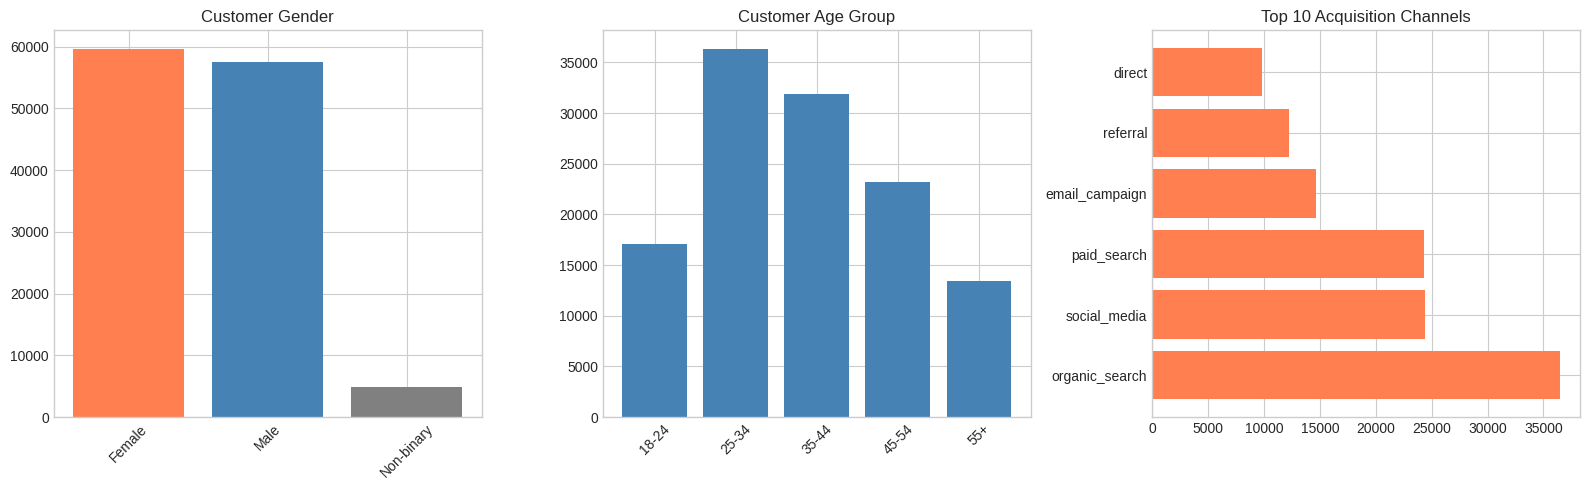

Total unique customers: 121,930
Missing gender:              0.0%
Missing age_group:           0.0%
Missing acquisition_channel: 0.0%

Customer signups by year:
signup_year
2012      957
2013     2989
2014     5034
2015     7133
2016     9202
2017    11078
2018    13011
2019    15058
2020    17211
2021    19154
2022    21103


In [22]:
# Cell 22: Customer Demographics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

gender = customers['gender'].value_counts(dropna=False)
axes[0].bar(gender.index.astype(str), gender.values, color=['coral','steelblue','grey'])
axes[0].set_title('Customer Gender')
axes[0].tick_params(axis='x', rotation=45)

age_group = customers['age_group'].value_counts(dropna=False).sort_index()
axes[1].bar(age_group.index.astype(str), age_group.values, color='steelblue')
axes[1].set_title('Customer Age Group')
axes[1].tick_params(axis='x', rotation=45)

acq = customers['acquisition_channel'].value_counts(dropna=False).head(10)
axes[2].barh(acq.index.astype(str), acq.values, color='coral')
axes[2].set_title('Top 10 Acquisition Channels')

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_10_customer_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total unique customers: {customers['customer_id'].nunique():,}")
print(f"Missing gender:              {customers['gender'].isna().mean()*100:.1f}%")
print(f"Missing age_group:           {customers['age_group'].isna().mean()*100:.1f}%")
print(f"Missing acquisition_channel: {customers['acquisition_channel'].isna().mean()*100:.1f}%")

# Customer signups over time
customers['signup_year'] = pd.to_datetime(customers['signup_date'], errors='coerce').dt.year
signups_by_year = customers['signup_year'].value_counts().sort_index()
print("\nCustomer signups by year:")
print(signups_by_year.to_string())


Revenue by Category:
              total_revenue  n_items  avg_price
category                                       
Streetwear 13131346352.6200   393533  7423.6923
Outdoor     2494882754.2000   259986  2131.7332
Casual       460648383.3500    23991  4295.6711
GenZ         343599095.3600    37159  2060.4533

Revenue by Segment:
              total_revenue  n_items
segment                             
Everyday    5376848662.2700   182533
Balanced    5127408523.4800   103333
Performance 2390412021.1700    96730
Activewear  2047815224.1800   230375
Premium      480131388.3900    31032
All-weather  427584524.9800    22570
Trendy       343599095.3600    37159
Standard     236677145.7000    10937


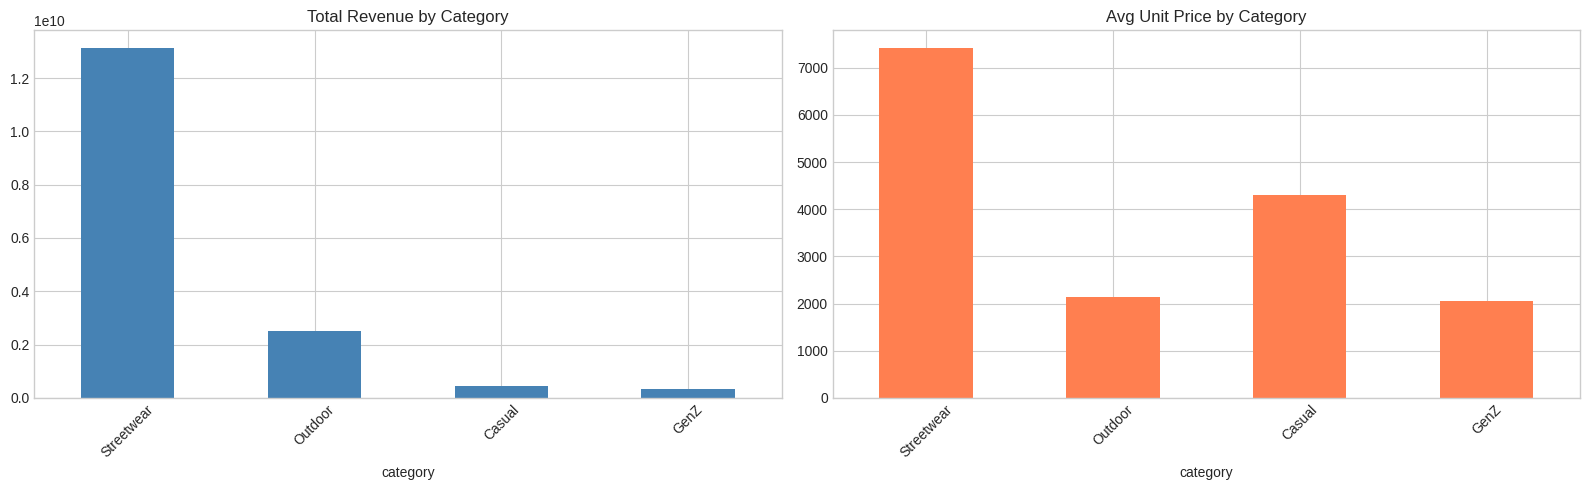

In [23]:
# Cell 23: Product Category Revenue Analysis
items_with_products = order_items.merge(
    orders[['order_id','order_date']], on='order_id', how='left'
).merge(
    products[['product_id','category','segment','price']], on='product_id', how='left'
)

cat_revenue = items_with_products.groupby('category').agg(
    total_revenue = ('unit_price', lambda x: (x * items_with_products.loc[x.index,'quantity']).sum()),
    n_items       = ('product_id', 'count'),
    avg_price     = ('unit_price', 'mean')
).sort_values('total_revenue', ascending=False)

seg_revenue = items_with_products.groupby('segment').agg(
    total_revenue = ('unit_price', lambda x: (x * items_with_products.loc[x.index,'quantity']).sum()),
    n_items       = ('product_id', 'count'),
).sort_values('total_revenue', ascending=False)

print("Revenue by Category:")
print(cat_revenue.to_string())
print("\nRevenue by Segment:")
print(seg_revenue.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cat_revenue['total_revenue'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Revenue by Category')
axes[0].tick_params(axis='x', rotation=45)

cat_revenue['avg_price'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Avg Unit Price by Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_11_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 10: Promotional Impact Analysis

Total promotions: 50
            promo_name  promo_type  discount_value start_date   end_date  stackable_flag
0     Spring Sale 2013  percentage         12.0000 2013-03-18 2013-04-17               1
1   Mid-Year Sale 2013  percentage         18.0000 2013-06-23 2013-07-22               0
2     Fall Launch 2013  percentage         10.0000 2013-08-30 2013-10-02               0
3   Year-End Sale 2013  percentage         20.0000 2013-11-18 2014-01-02               0
4   Urban Blowout 2013       fixed         50.0000 2013-07-30 2013-09-02               0
5   Rural Special 2013  percentage         15.0000 2013-01-31 2013-03-01               0
6     Spring Sale 2014  percentage         12.0000 2014-03-18 2014-04-17               1
7   Mid-Year Sale 2014  percentage         18.0000 2014-06-23 2014-07-22               0
8     Fall Launch 2014  percentage         10.0000 2014-08-30 2014-10-01               0
9   Year-End Sale 2014  percentage         20.0000 2014-11-19 2015-01-02               0


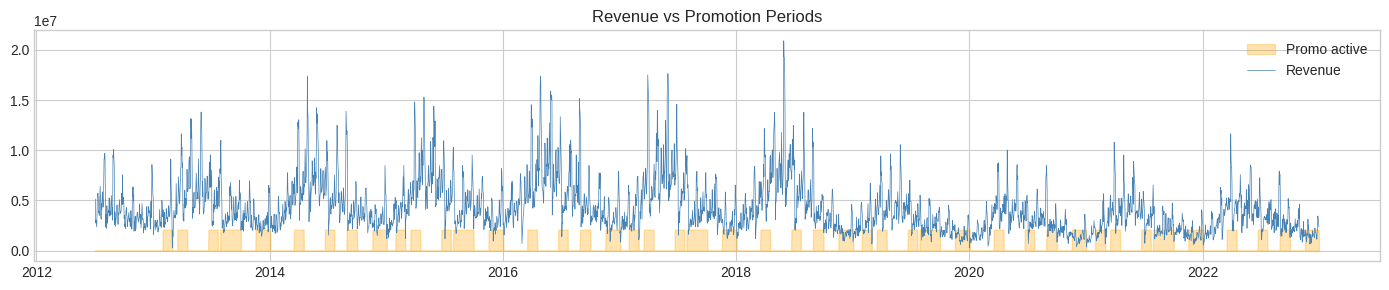

In [24]:
# Cell 24: Promotional Impact
print(f"Total promotions: {len(promotions)}")
display_cols = [c for c in ['promo_name','promo_type','discount_value','start_date','end_date','stackable_flag'] if c in promotions.columns]
print(promotions[display_cols].to_string())

# Build daily promo-active flag
all_promo_dates = set()
for _, row in promotions.iterrows():
    if pd.notna(row.get('start_date')) and pd.notna(row.get('end_date')):
        dates = pd.date_range(row['start_date'], row['end_date'], freq='D')
        all_promo_dates.update(dates.date.tolist())

sales['promo_active'] = sales['Date'].dt.date.isin(all_promo_dates).astype(int)

promo_days   = sales[sales['promo_active']==1]['Revenue']
nopromo_days = sales[sales['promo_active']==0]['Revenue']

print(f"\nPromo active days: {len(promo_days)} | Avg Revenue: {promo_days.mean():,.0f}")
print(f"No promo days:     {len(nopromo_days)} | Avg Revenue: {nopromo_days.mean():,.0f}")
if nopromo_days.mean() > 0:
    lift = (promo_days.mean()/nopromo_days.mean()-1)*100
    print(f"Promo lift: {lift:+.1f}%")
else:
    lift = 0.0

u_stat, u_p = stats.mannwhitneyu(promo_days, nopromo_days, alternative='two-sided')
print(f"Mann-Whitney U test p-value: {u_p:.6f} ({'significant' if u_p < 0.05 else 'not significant'})")

findings['temporal_patterns']['promo_lift_pct']  = round(float(lift), 2)
findings['temporal_patterns']['promo_significant'] = bool(u_p < 0.05)

# Promotion timeline
fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(sales['Date'], sales['promo_active']*sales['Revenue'].max()*0.1, alpha=0.3, color='orange', label='Promo active')
ax.plot(sales['Date'], sales['Revenue'], lw=0.5, color='steelblue', label='Revenue')
ax.set_title('Revenue vs Promotion Periods')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_12_promo_impact.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 11: Inventory Analysis

Inventory shape: (60247, 17)
Inventory date range: 2012-07-31 → 2022-12-31
       stock_on_hand  fill_rate  stockout_days  sell_through_rate
count     60247.0000 60247.0000     60247.0000         60247.0000
mean        189.2985     0.9613         1.1606             0.1523
std         316.9761     0.0542         1.6245             0.1393
min           3.0000     0.0667         0.0000             0.0004
25%          15.0000     0.9333         0.0000             0.0421
50%          62.0000     0.9667         1.0000             0.1111
75%         210.0000     1.0000         2.0000             0.2381
max        2673.0000     1.0000        28.0000             0.8531

Stockout rate:  67.3% of product-months
Overstock rate: 76.3% of product-months


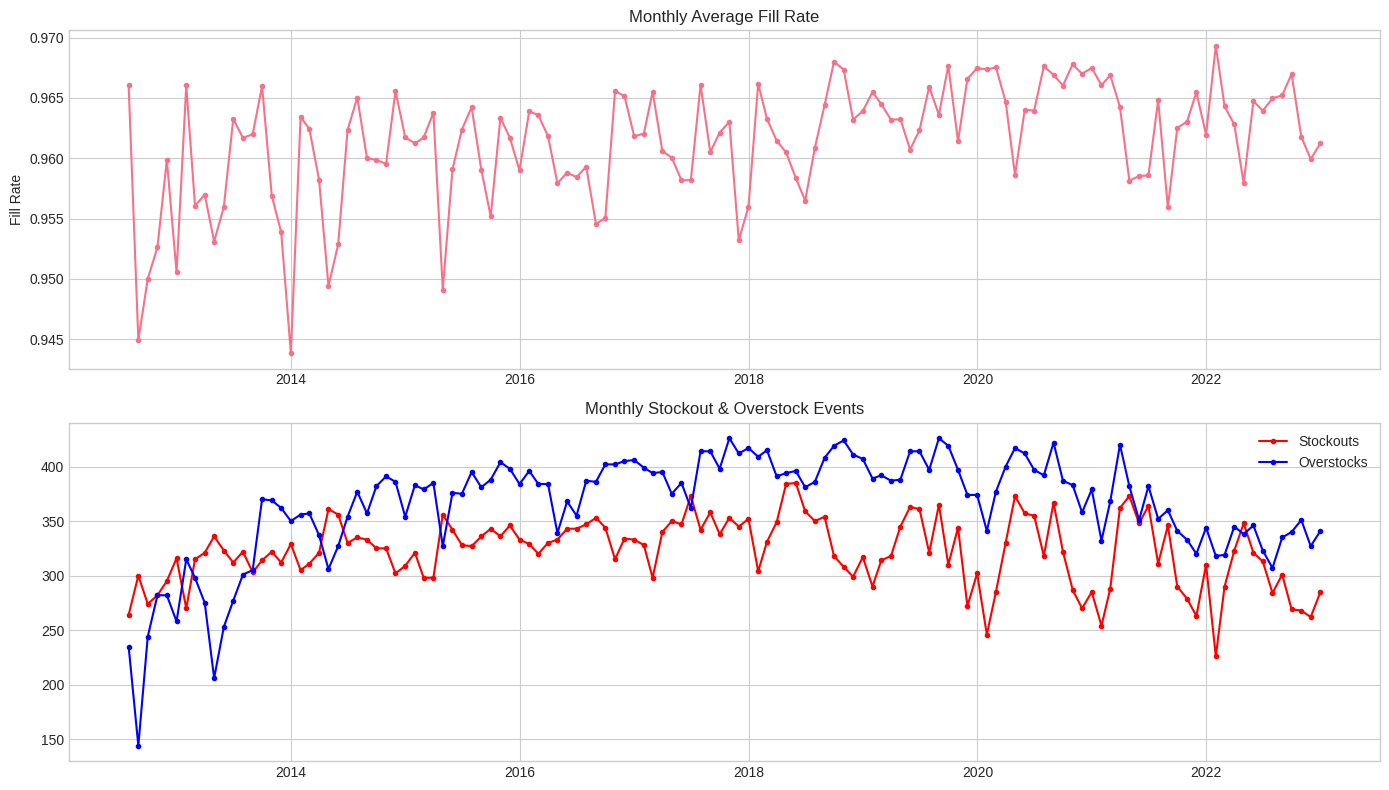

In [25]:
# Cell 25: Inventory Analysis
print(f"Inventory shape: {inventory.shape}")
print(f"Inventory date range: {inventory['snapshot_date'].min().date()} → {inventory['snapshot_date'].max().date()}")

inv_numeric = ['stock_on_hand','fill_rate','stockout_days','sell_through_rate']
inv_cols_present = [c for c in inv_numeric if c in inventory.columns]
print(inventory[inv_cols_present].describe())

if 'stockout_flag' in inventory.columns:
    stockout_rate  = inventory['stockout_flag'].mean()
    print(f"\nStockout rate:  {stockout_rate*100:.1f}% of product-months")
if 'overstock_flag' in inventory.columns:
    overstock_rate = inventory['overstock_flag'].mean()
    print(f"Overstock rate: {overstock_rate*100:.1f}% of product-months")

# Monthly aggregate
agg_dict = {}
if 'fill_rate'       in inventory.columns: agg_dict['avg_fill_rate']    = ('fill_rate',       'mean')
if 'stockout_flag'   in inventory.columns: agg_dict['total_stockout']   = ('stockout_flag',   'sum')
if 'overstock_flag'  in inventory.columns: agg_dict['total_overstock']  = ('overstock_flag',  'sum')
if 'sell_through_rate' in inventory.columns: agg_dict['avg_sell_through'] = ('sell_through_rate','mean')

if agg_dict:
    inv_monthly = inventory.groupby('snapshot_date').agg(**agg_dict).reset_index()

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    if 'avg_fill_rate' in inv_monthly.columns:
        axes[0].plot(inv_monthly['snapshot_date'], inv_monthly['avg_fill_rate'], marker='o', ms=3)
        axes[0].set_title('Monthly Average Fill Rate')
        axes[0].set_ylabel('Fill Rate')

    if 'total_stockout' in inv_monthly.columns:
        axes[1].plot(inv_monthly['snapshot_date'], inv_monthly['total_stockout'],  color='red',  marker='o', ms=3, label='Stockouts')
    if 'total_overstock' in inv_monthly.columns:
        axes[1].plot(inv_monthly['snapshot_date'], inv_monthly['total_overstock'], color='blue', marker='o', ms=3, label='Overstocks')
    axes[1].set_title('Monthly Stockout & Overstock Events')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(OUT_DIR + 'fig_13_inventory_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No numeric inventory flags found to aggregate.")


## Section 12: Feature Engineering Insights (Lags & Rolling)

Lag Autocorrelation with Revenue:
  Lag    1d: +0.8655 █████████████████████████
  Lag    2d: +0.7351 ██████████████████████
  Lag    3d: +0.6216 ██████████████████
  Lag    7d: +0.4920 ██████████████
  Lag   14d: +0.4964 ██████████████
  Lag   21d: +0.4369 █████████████
  Lag   30d: +0.6523 ███████████████████
  Lag   60d: +0.5000 ███████████████
  Lag   90d: +0.3277 █████████
  Lag  180d: -0.0442 █
  Lag  365d: +0.7898 ███████████████████████


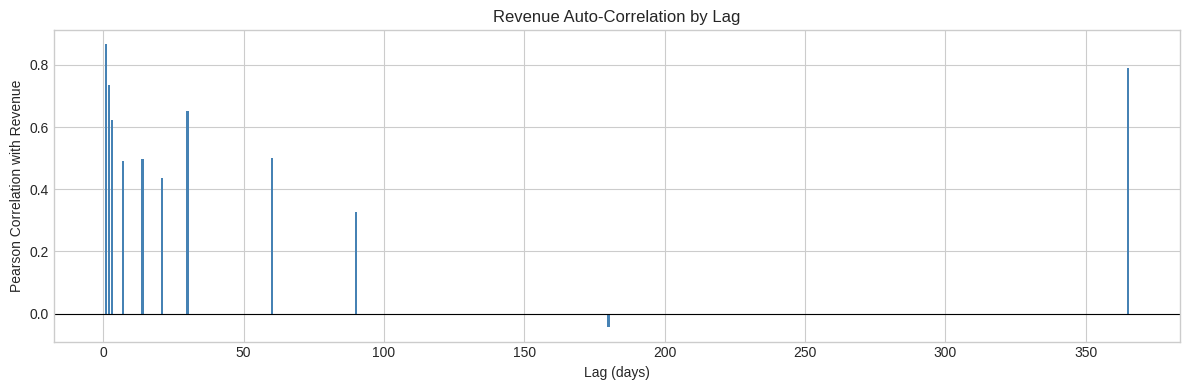

In [26]:
# Cell 26: Lag Analysis
lag_days = [1, 2, 3, 7, 14, 21, 30, 60, 90, 180, 365]
lag_corrs = {}
for lag in lag_days:
    lagged = sales['Revenue'].shift(lag)
    valid  = sales['Revenue'].notna() & lagged.notna()
    corr   = float(sales['Revenue'][valid].corr(lagged[valid]))
    lag_corrs[lag] = round(corr, 4)

print("Lag Autocorrelation with Revenue:")
for lag, corr in lag_corrs.items():
    bar = '█' * int(abs(corr) * 30)
    print(f"  Lag {lag:>4}d: {corr:+.4f} {bar}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(list(lag_corrs.keys()), list(lag_corrs.values()), color='steelblue')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Pearson Correlation with Revenue')
ax.set_title('Revenue Auto-Correlation by Lag')
ax.axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_14_lag_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

findings['lag_analysis'] = {
    "lag_correlations": lag_corrs,
    "best_lag":    max(lag_corrs, key=lambda k: abs(lag_corrs[k])),
    "lag_7_corr":  lag_corrs.get(7),
    "lag_365_corr": lag_corrs.get(365)
}


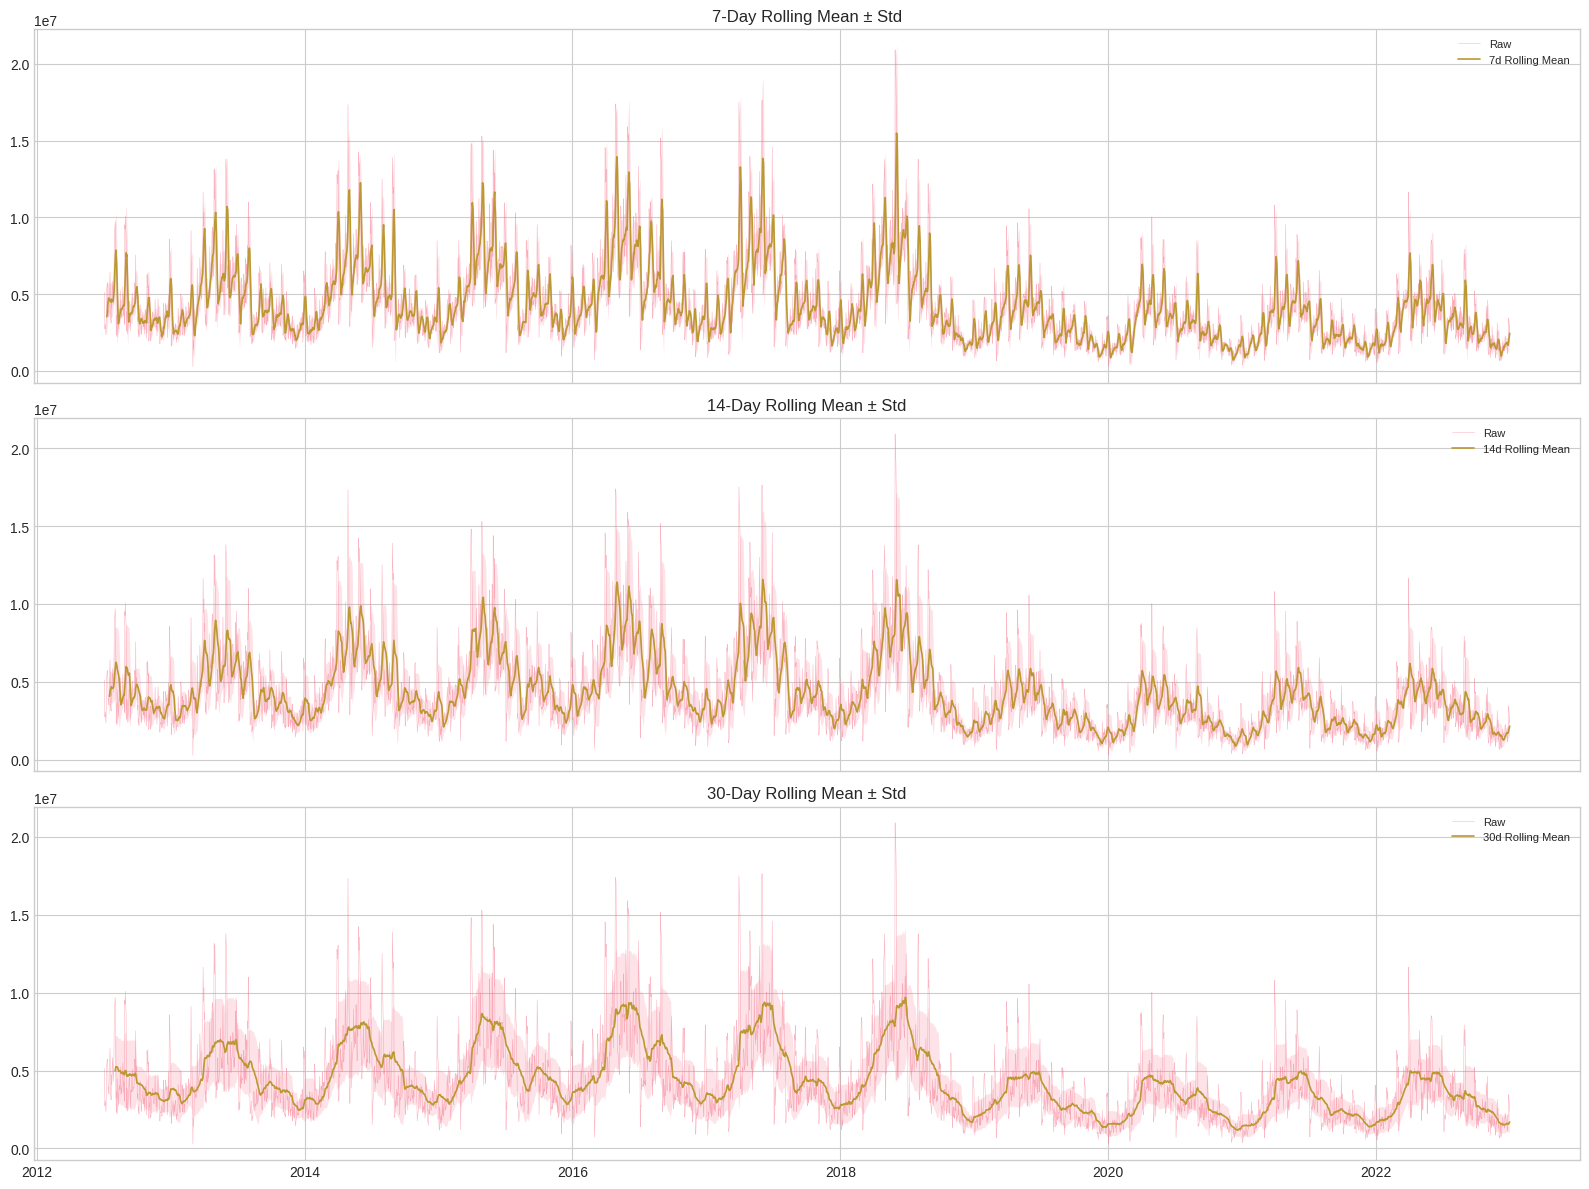


Mutual Information Scores (vs Revenue):
rev_lag1       0.7944
rev_lag365     0.5179
roll7_mean     0.5101
roll30_mean    0.4257
doy            0.4026
rev_lag7       0.3549
month          0.2591
rev_lag14      0.2450
roll7_std      0.1894
quarter        0.1767
dow            0.0158
tet_season     0.0108
is_holiday     0.0035
promo_active   0.0000


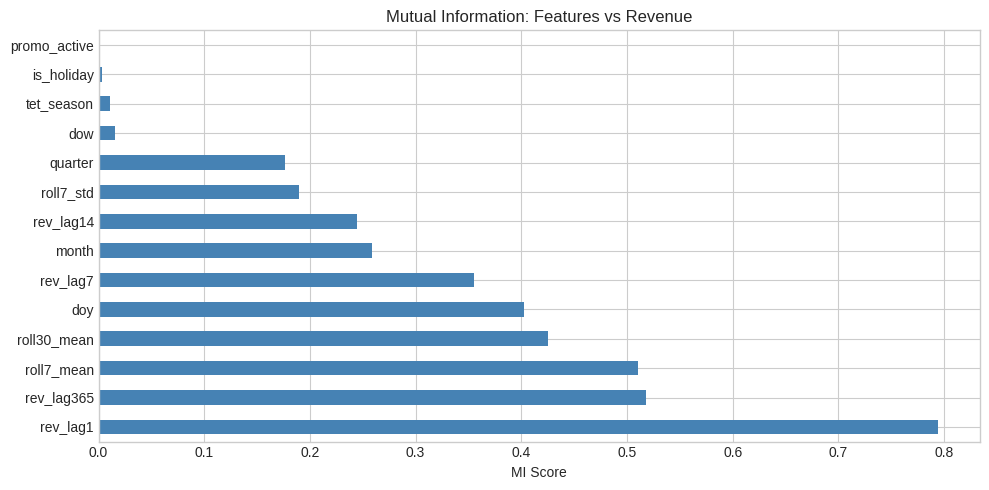

In [27]:
# Cell 27: Rolling Window Features
windows = [7, 14, 30]
fig, axes = plt.subplots(len(windows), 1, figsize=(16, 4*len(windows)), sharex=True)

for ax, w in zip(axes, windows):
    roll_mean = sales['Revenue'].rolling(w).mean()
    roll_std  = sales['Revenue'].rolling(w).std()
    ax.plot(sales['Date'], sales['Revenue'], lw=0.4, alpha=0.5, label='Raw')
    ax.plot(sales['Date'], roll_mean, lw=1.2, label=f'{w}d Rolling Mean')
    ax.fill_between(sales['Date'], roll_mean - roll_std, roll_mean + roll_std, alpha=0.2)
    ax.set_title(f'{w}-Day Rolling Mean ± Std')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_15_rolling_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Mutual information between engineered features and Revenue
mi_features = pd.DataFrame({
    'rev_lag1':    sales['Revenue'].shift(1),
    'rev_lag7':    sales['Revenue'].shift(7),
    'rev_lag14':   sales['Revenue'].shift(14),
    'rev_lag365':  sales['Revenue'].shift(365),
    'roll7_mean':  sales['Revenue'].rolling(7).mean().shift(1),
    'roll30_mean': sales['Revenue'].rolling(30).mean().shift(1),
    'roll7_std':   sales['Revenue'].rolling(7).std().shift(1),
    'dow':         sales['dow'],
    'month':       sales['month'],
    'quarter':     sales['quarter'],
    'doy':         sales['doy'],
    'is_holiday':  sales['is_holiday'],
    'tet_season':  sales['is_tet_window'],
    'promo_active': sales['promo_active'],
}).dropna()

target_aligned = sales.loc[mi_features.index, 'Revenue']
mi_scores = mutual_info_regression(mi_features, target_aligned, random_state=42)
mi_df = pd.Series(mi_scores, index=mi_features.columns).sort_values(ascending=False)

print("\nMutual Information Scores (vs Revenue):")
print(mi_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
mi_df.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Mutual Information: Features vs Revenue')
ax.set_xlabel('MI Score')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_16_mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

findings['lag_analysis']['mutual_information'] = {col: round(float(v), 4) for col, v in mi_df.items()}


## Section 13: External Data Horizon Gap & Model Recommendations

In [28]:
# Cell 28: Horizon Gap & Recommendations
print("=" * 60)
print("CRITICAL ARCHITECTURAL CONSTRAINT")
print("=" * 60)
print("""
ALL external datasets (web traffic, inventory, orders, etc.)
end at 2022-12-31. Test period starts 2023-01-01.

For the 548-day test horizon, only available inputs are:
  1. Historical Revenue & COGS values (sales.csv)
  2. Calendar features (DOW, month, quarter, doy, holiday, Tet)

This eliminates exogenous-feature models (ARIMAX with real
external variables, LightGBM with transactional features).

This favors:
  ✓ SARIMA / SARIMAX with calendar-only exogenous
  ✓ Facebook Prophet (multi-seasonality + VN holidays)
  ✓ LightGBM/XGBoost with lag + calendar features only
  ✓ N-BEATS / N-HiTS (univariate neural)
  ✓ Theta / ETS (robust seasonal baseline)
""")

recommendations = [
    {
        "priority": 1,
        "model": "Facebook Prophet",
        "reason": "Multi-period seasonality (weekly + annual). Natively handles Vietnamese holiday calendar via custom holidays. Tet modeling via add_country_holidays('VN'). Robust to outliers (robust=True). Directly outputs uncertainty intervals.",
        "requires_external_data": False
    },
    {
        "priority": 2,
        "model": "LightGBM (lag + calendar features)",
        "reason": "Tree-based model using lag features (lag1, lag7, lag14, lag365), rolling statistics, and calendar features. No external features needed at test time. Fast to iterate. Handles non-linearities well.",
        "requires_external_data": False
    },
    {
        "priority": 3,
        "model": "SARIMA / SARIMAX",
        "reason": "Classic statistical model. SARIMA(p,d,q)(P,D,Q)[7] for weekly seasonality with yearly via Fourier terms. ADF/KPSS tests guide d parameter. Calendar features as exogenous (SARIMAX).",
        "requires_external_data": False
    },
    {
        "priority": 4,
        "model": "N-BEATS / N-HiTS",
        "reason": "Pure univariate deep learning. Strong on M competition benchmarks for daily 500+ day horizons. No feature engineering required. Decomposition architecture handles trend + seasonality.",
        "requires_external_data": False
    },
    {
        "priority": 5,
        "model": "Theta / ETS Ensemble",
        "reason": "Simple, interpretable baseline hard to beat on seasonal data. Use as ensemble component. ETS handles multiplicative seasonality if needed.",
        "requires_external_data": False
    }
]

findings['recommended_models'] = recommendations
print("Model recommendations:")
for m in recommendations:
    print(f"  {m['priority']}. {m['model']}")


CRITICAL ARCHITECTURAL CONSTRAINT

ALL external datasets (web traffic, inventory, orders, etc.)
end at 2022-12-31. Test period starts 2023-01-01.

For the 548-day test horizon, only available inputs are:
  1. Historical Revenue & COGS values (sales.csv)
  2. Calendar features (DOW, month, quarter, doy, holiday, Tet)

This eliminates exogenous-feature models (ARIMAX with real
external variables, LightGBM with transactional features).

This favors:
  ✓ SARIMA / SARIMAX with calendar-only exogenous
  ✓ Facebook Prophet (multi-seasonality + VN holidays)
  ✓ LightGBM/XGBoost with lag + calendar features only
  ✓ N-BEATS / N-HiTS (univariate neural)
  ✓ Theta / ETS (robust seasonal baseline)

Model recommendations:
  1. Facebook Prophet
  2. LightGBM (lag + calendar features)
  3. SARIMA / SARIMAX
  4. N-BEATS / N-HiTS
  5. Theta / ETS Ensemble


## Section 14: Export Findings

In [29]:
# Cell 29: Export findings.json
import json

output_path = OUT_DIR + 'findings.json'
with open(output_path, 'w') as f:
    json.dump(findings, f, indent=2, default=str)

print(f"Saved findings.json: {output_path}")
print(f"Top-level keys: {list(findings.keys())}")

# Verify completeness
empty_keys = [k for k,v in findings.items() if not v]
if empty_keys:
    print(f"WARNING: Empty sections: {empty_keys}")
else:
    print("All sections populated.")


Saved findings.json: ../eda_results/findings.json
Top-level keys: ['problem', 'external_availability', 'data_quality', 'target_stats', 'stationarity', 'seasonality', 'autocorrelation', 'temporal_patterns', 'transaction_features', 'correlation_with_revenue', 'outliers', 'lag_analysis', 'recommended_models']
All sections populated.


In [30]:
# Cell 30: Generate eda_results/report.md
stationarity = findings.get('stationarity', {})
seasonality  = findings.get('seasonality', {})
autocorr     = findings.get('autocorrelation', {})
outliers_f   = findings.get('outliers', {})
target_stats = findings.get('target_stats', {}).get('revenue', {})
temporal     = findings.get('temporal_patterns', {})
lag_anal     = findings.get('lag_analysis', {})
rec_models   = findings.get('recommended_models', [])
ext_avail    = findings.get('external_availability', {})

report = f"""# EDA Report — Datathon 2026 Revenue Forecasting
Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}

## Problem
- **Targets:** Revenue + COGS (both required in submission)
- **Train:** 2012-07-04 → 2022-12-31 (3,833 daily rows)
- **Test:**  2023-01-01 → 2024-07-01 (548 days)
- **Evaluation:** MAE, RMSE, R²

## CRITICAL Architectural Constraint
> ALL external datasets (web_traffic, inventory, orders, etc.) end 2022-12-31.
> Zero external features are available for the test period (2023-2024).
> Models must rely solely on historical Revenue/COGS and calendar features.

## Target Variable — Revenue
| Metric   | Value |
|----------|-------|
| Mean     | {target_stats.get('mean',0):,.0f} |
| Median   | {target_stats.get('median',0):,.0f} |
| Std      | {target_stats.get('std',0):,.0f} |
| CV       | {target_stats.get('cv',0):.4f} |
| Min      | {target_stats.get('min',0):,.0f} |
| Max      | {target_stats.get('max',0):,.0f} |
| Distribution | {outliers_f.get('distribution_recommendation','unknown')} |
| Outliers (3×IQR) | {outliers_f.get('revenue_outliers_3iqr','N/A')} |

## Stationarity
| Test | p-value | Conclusion |
|------|---------|------------|
| ADF  | {stationarity.get('adf',{}).get('p_value','N/A')} | {'Stationary' if stationarity.get('adf',{}).get('stationary_at_05') else 'Non-Stationary'} |
| KPSS | {stationarity.get('kpss',{}).get('p_value','N/A')} | {'Stationary' if stationarity.get('kpss',{}).get('stationary_at_05') else 'Non-Stationary'} |
| ADF after diff(1) | {stationarity.get('adf_after_diff1',{}).get('p_value','N/A')} | {'Stationary' if stationarity.get('adf_after_diff1',{}).get('stationary') else 'Non-Stationary'} |

Differencing needed: **{stationarity.get('differencing_needed', 'Unknown')}**

## Seasonality (STL)
- Seasonality Strength Fs: **{seasonality.get('seasonality_strength_Fs','N/A')}** ({'Strong' if seasonality.get('strong_seasonality') else 'Weak'} — threshold 0.6)
- Trend Strength Ft: **{seasonality.get('trend_strength_Ft','N/A')}** ({'Strong' if seasonality.get('strong_trend') else 'Weak'})

## Key Temporal Patterns
- **Tet-season lift:** {temporal.get('tet_lift_pct','N/A')}%
- **Holiday lift:** {temporal.get('holiday_lift_pct','N/A')}%
- **Promo lift:** {temporal.get('promo_lift_pct','N/A')}% (statistically significant: {temporal.get('promo_significant', False)})
- **YoY growth:** mean={temporal.get('yoy_growth_mean',0)*100:.1f}%, std={temporal.get('yoy_growth_std',0)*100:.1f}%

## ACF Key Lags
- Lag-1:  {autocorr.get('lag_1_acf','N/A')}
- Lag-7:  {autocorr.get('lag_7_acf','N/A')}
- Lag-30: {autocorr.get('lag_30_acf','N/A')}

## Best Lag Features (Mutual Information)
"""

mi_scores = lag_anal.get('mutual_information', {})
if mi_scores:
    sorted_mi = sorted(mi_scores.items(), key=lambda x: -x[1])
    for feat, score in sorted_mi[:8]:
        report += f"- `{feat}`: {score}\n"

report += f"""
## Recommended Models (Ranked)
"""
for m in rec_models:
    report += f"\n### {m['priority']}. {m['model']}\n{m['reason']}\n"

report += "\n## Generated Figures\n"
for fig_name in sorted(f for f in os.listdir(OUT_DIR) if f.endswith('.png')):
    report += f"- `{fig_name}`\n"

with open(OUT_DIR + 'report.md', 'w') as f:
    f.write(report)

print("Saved eda_results/report.md")
print(f"Report length: {len(report)} characters")


Saved eda_results/report.md
Report length: 3351 characters


In [31]:
# Cell 31: Final Summary
print("=" * 60)
print("EDA COMPLETE")
print("=" * 60)
print(f"Figures saved:  {len([f for f in os.listdir(OUT_DIR) if f.endswith('.png')])}")
print(f"Parquet files:  {len(list(__import__('pathlib').Path(PROC_DIR).glob('*.parquet')))}")
print(f"findings.json:  {os.path.exists(OUT_DIR + 'findings.json')}")
print(f"report.md:      {os.path.exists(OUT_DIR + 'report.md')}")


EDA COMPLETE
Figures saved:  18
Parquet files:  4
findings.json:  True
report.md:      True
